# SR critic vs Base — one row per (algorithm, environment)

**Standalone.** Data is pulled from wandb once and cached, so re-runs are offline.

Every row compares a **Base** critic against an **SR** (successor-representation) critic on one
algorithm and one environment. The two arms come from different sweeps, so a row is really a
pair of sweep references plus a filter — which is all `ROWS` holds. Adding a row is appending a
spec; nothing else changes.

| row | algo | env | Base sweep | SR sweep |
|---|---|---|---|---|
| 1 | OnCRPO | `SafetyPointGoal1-v0` | `c0s6vcsa` | `stn3j03z` |
| 2 | OnCRPO | `SafetyPointButton1-v0` | `c0s6vcsa` | `stn3j03z` |

Both arms are scored **inside their own pool** by `SELECT["criterion"]`, over whatever that
sweep's grid actually varies — two knobs for Base, seven for SR — so each arm is shown at its
own best config rather than at one shared setting that only suits one of them.

### The four columns

1. **Trajectory** — the path through (total cost, episode return), read at several checkpoints
2. **Estimation error** — $\hat V_c - \tilde V_c$ on the eval probes; above zero over-predicts
3. **Correlation (cost)** — Corr($\hat V_c$, $\tilde V_c$) on the eval probes
4. **Choosable** — `COL4` selects AUROC (cost), ECE (cost), or the signed error of the
   intermediate value group

Columns 1–3 come from logged scalars. **Column 4 does not**: none of its three options is
logged, so it is computed from the raw `eval_data` probes and needs those artifacts on disk
(~330 MB per row). Section 6 fetches them on demand, per row.

### Layout

1. **Config** — the rows, the selection criterion, the column-4 choice
2. **Style** — `STYLE` and `TEXT`
3. **Utilities** — fetching, selection, probe metrics, drawing
4. **Load** — summaries, config choices and history for columns 1–3
5. **The figure** (columns 1–3)
6. **Column 4** — probes, fetched per row
7. **One pairing, every metric** — the same four columns, column 4 varying down the rows
8. **Pinned estimator** — section 5 again, with every arm restricted to one `adv`
10. **Both algorithms on one row** — CPO and PIDLag, Base and SR, all on `plain`

## 1. Config

In [ ]:
import pathlib
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon

# Repo-anchored, so the same cache is used wherever the kernel starts.
REPO = pathlib.Path.cwd().resolve()
while not (REPO / "omnisafe").is_dir() and not (REPO / "plots").is_dir():
    if REPO.parent == REPO:
        raise RuntimeError("could not find the MICE repo root")
    REPO = REPO.parent

ENTITY_PROJECT = "liam-paull/calibration_rl"
DATA_DIR = REPO / "figs" / "sr_vs_base"
FIG_DIR = DATA_DIR / "figures"
PROBE_DIR = DATA_DIR / "probes"
for _d in (FIG_DIR, PROBE_DIR):
    _d.mkdir(parents=True, exist_ok=True)

ARMS = ["Base", "SR"]            # fixed: every row is this comparison, in this order

# One row per (algorithm, environment).  `arms` names the sweep each arm comes from; the two
# may be the same sweep with different filters, or different sweeps entirely.
ROWS = [
    dict(label="CPO · PointGoal1", algo="CPO", env="SafetyPointGoal1-v0",
         arms={"Base": dict(sweep="hyfcu0dx"), "SR": dict(sweep="260zwq3s")}),
    dict(label="PIDLag · PointGoal1", algo="TRPOPID", env="SafetyPointGoal1-v0",
         arms={"Base": dict(sweep="hyfcu0dx"), "SR": dict(sweep="84vmrbam")}),
]

SELECT = {"criterion": "ratio"}   # "ratio" | "EpRet" | "avg_ep_cost" -- see CRITERIA in 3.2

# Column 4.  None of these is logged; all three are computed from the eval_data probes.
COL4 = "intermediate_error"       # "auroc" | "ece" | "intermediate_error"

GAMMA, COST_LIMIT = 0.99, 10.0
T_LOW, T_HIGH = GAMMA ** 500, GAMMA ** 5      # value-group edges, as in fig2
# Fixed bins of the Monte-Carlo reference for the calibration error.  Fixed rather than
# per-checkpoint quantiles so a bin means the same band of true cost at every step and
# for every arm; the first two edges are the value-group cuts, so the first two bins are
# exactly the low and intermediate groups and the rest subdivide the high one.
ECE_EDGES = [-np.inf, T_LOW, T_HIGH, 2.0, 5.0, 10.0, np.inf]
MIN_STEPS_FRAC = 0.95

CHECKPOINTS = [1e6, 2.5e6, 5e6, 7.5e6, 1e7]    # where column 1 reads each trajectory

# Config keys that are never part of a grid worth searching over.
IGNORE_PARAMS = {"device", "env-id", "algo", "seed", "cost-limit", "early-eval-freq"}

HISTORY_KEYS = [
    "TotalEnvSteps", "Metrics/EpRet", "Metrics/EpCost", "Metrics/TotalCost", "Metrics/EpLen",
    "PooledMC/Correlation_c", "PooledMC/Correlation_r", "PooledMC/EstimationError_c",
]

print("repo  :", REPO)
print("cache :", DATA_DIR)
print("rows  :", " | ".join(r["label"] for r in ROWS))
print("col 4 :", COL4)

repo  : /home/kaustubh/projects/calibration_rl/MICE
cache : /home/kaustubh/projects/calibration_rl/MICE/figs/sr_vs_base
rows  : CPO · PointGoal1 | PIDLag · PointGoal1 | PIDLag · PointGoal2
col 4 : intermediate_error


## 2. Style

`STYLE` is the palette, type, marks and panel geometry; `TEXT` is every string. Geometry is
**inches per panel**, so panels keep the same physical size however many rows there are.

Colour means **arm** — Base against SR — in every panel and every row, using the Okabe-Ito
hues the other notebooks use. The pair was checked: colour-vision separation ΔE 18.7, both
clearing 3:1 contrast against white.

In [ ]:
STYLE = {
    "arm": {"Base": "#0072B2", "SR": "#D55E00"},
    "ink": {"title": "#1a1a1a", "label": "#5a5a5a", "spine": "#909090",
            "tick": "#8a8a8a", "grid": "#d8d8d8", "rule": "#5a5a5a"},

    "font": {"family": "DejaVu Sans", "title": 26, "label": 24, "tick": 19,
             "note": 18, "legend": 28, "suptitle": 30, "row": 25},

    "line": {"width": 2.2, "marker": 5, "band_alpha": 0.16,
             "grid": 1.0, "spine": 1.0, "tick_len": 3.6, "tick_width": 1.0,
             "rule_width": 1.7, "rule_dash": (0, (5, 3)),
             "ellipse_alpha": 0.18, "ellipse_edge": 1.4,
             "traj_width": 1.8, "traj_marker": 5.0, "traj_marker_grow": 1.7},

    # inches
    # Panels scale with the type: at font 26 a 4.30in panel could not hold
    # "AUROC (high value) (cost)" without spilling into its neighbour.
    "panel": {"w": 4.90, "h": 4.40, "wgap": 0.86, "hgap": 1.05,
              "left": 1.20, "right": 0.14, "top": 0.60, "bottom": 1.10,
              "rowlab": 1.15},

    "band": "sem",
    "dpi": 300, "pad_inches": 0.1,
    "xticks": [3e4, 1e5, 3e5, 1e6, 3e6, 1e7],
}

COL4_TEXT = {
    "auroc": ("Eval, Pred vs MC truth", "AUROC (cost)"),
    "ece": ("Eval, Pred vs MC truth", "ECE (cost)"),
    "correlation": ("Eval, Pred vs MC truth", "Correlation (cost)"),
    "low_error": ("Eval, low group", "Estimation error (cost)"),
    "intermediate_error": ("Eval, intermediate group", "Estimation error (cost)"),
    "high_error": ("Eval, high group", "Estimation error (cost)"),
}

# Short names for the row labels of section 7.  The three group errors share a quantity,
# so naming them by that alone would leave three rows labelled identically.
COL4_LABEL = {
    "auroc": "AUROC (cost)",
    "ece": "ECE (cost)",
    "low_error": "Signed error\nlow group",
    "intermediate_error": "Signed error\nintermediate group",
    "high_error": "Signed error\nhigh group",
}

TEXT = {
    # First line is the context, second the quantity -- as in fig3/fig5.
    "titles": ["Trajectory\nReturn vs total cost",
               "Eval, Pred vs MC truth\nEstimation error (cost)",
               "Eval, Pred vs MC truth\nCorrelation (cost)"],
    "xlabel_steps": "Total env steps",
    "traj_x": "Total cost",
    "traj_y": "Episode return",
    "cost_limit": "cost limit",
    "legend_title": None,
    "suptitle": "SR critic vs Base, by algorithm and environment",
    "suptitle_metrics": "SR critic vs Base — {row}",
    "suptitle_biased": "SR critic vs Base, {bias}",
    "col4_per_row": "Eval\n(metric named at left)",
}


def apply_style():
    """Push STYLE into rcParams. Re-run after editing STYLE."""
    f, l, ink = STYLE["font"], STYLE["line"], STYLE["ink"]
    mpl.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": STYLE["dpi"],
        "font.family": "sans-serif", "font.sans-serif": [f["family"]], "font.size": f["tick"],
        "axes.titlesize": f["title"], "axes.titlecolor": ink["title"], "axes.titlepad": 8,
        "axes.labelsize": f["label"], "axes.labelcolor": ink["label"],
        "axes.edgecolor": ink["spine"], "axes.linewidth": l["spine"],
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True,
        "grid.color": ink["grid"], "grid.linewidth": l["grid"], "grid.alpha": 1.0,
        "xtick.labelsize": f["tick"], "ytick.labelsize": f["tick"],
        "xtick.color": ink["tick"], "ytick.color": ink["tick"],
        "xtick.labelcolor": ink["label"], "ytick.labelcolor": ink["label"],
        "xtick.direction": "out", "ytick.direction": "out",
        "xtick.major.size": l["tick_len"], "ytick.major.size": l["tick_len"],
        "xtick.major.width": l["tick_width"], "ytick.major.width": l["tick_width"],
        "xtick.minor.visible": False, "ytick.minor.visible": False,
        "legend.fontsize": f["legend"], "legend.frameon": False,
    })


apply_style()
ACOLOR = STYLE["arm"]
print("style applied |", ACOLOR, "| col4:", " / ".join(COL4_TEXT[COL4]))

style applied | {'Base': '#0072B2', 'SR': '#D55E00'} | col4: Eval, intermediate group / Estimation error (cost)


## 3. Utilities

**3.1** fetching and caching, **3.2** config selection, **3.3** the probe metrics behind
column 4, **3.4** drawing primitives.

### 3.1 Fetching and caching

In [3]:
def save_csv(df, path):
    """Write via temp + rename, so an interrupted run leaves no half-written cache."""
    tmp = str(path) + ".tmp"
    df.to_csv(tmp, index=False)
    pathlib.Path(tmp).replace(path)


def to_numeric(df, cols):
    """Force numeric dtype.

    wandb's history() returns a sparsely-logged column (the PooledMC keys, present only at
    eval epochs) as dtype=object, while the same data via CSV comes back float64.
    """
    for c in cols:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


SUMMARY_PAGE = 500          # runs per API page
SUMMARY_WORKERS = 16        # concurrent summary reads


def fetch_summary(sweep_id, algo=None, env=None):
    """One row per run: every grid parameter of that sweep, plus its end-of-training summary.

    The grid is read off the sweep rather than hard-coded, because Base and SR vary quite
    different knobs -- two against seven -- and a row may pair any two sweeps.

    Only the summary is pulled here, never history or artifacts, and `algo`/`env` push the
    row's filter to the server: a sweep spanning two environments is half the walk when a
    row draws one of them.  Paging SUMMARY_PAGE at a time rather than the default 50 turns
    a 960-run sweep from twenty round trips into two.

    The real cost is elsewhere: these runs log a summary too large to travel in the page
    payload, so reading `r.summary` is one HTTP round trip *per run* (~280 ms measured).
    Paging is nearly free by comparison, so the reads are done on a thread pool; the page
    itself already carries `config` and `state`, which cost nothing.
    """
    import wandb
    api = wandb.Api(timeout=300)
    sweep = api.sweep(f"{ENTITY_PROJECT}/{sweep_id}")
    params = [k for k in sweep.config.get("parameters", {}) if k not in IGNORE_PARAMS]
    filters = {"sweep": sweep_id}
    if algo is not None:
        filters["config.algo"] = algo
    if env is not None:
        filters["config.env-id"] = env
    runs = list(api.runs(ENTITY_PROJECT, filters=filters, per_page=SUMMARY_PAGE))

    def one(r):
        c = r.config                      # from the page payload -- free
        d = {p: c.get(p) for p in params}
        s = r.summary                     # the round trip this pool exists to overlap
        d.update(run_id=r.id, state=r.state, seed=c.get("seed"),
                 algo=c.get("algo"), env=c.get("env-id"),
                 EpRet=s.get("Metrics/EpRet"), EpLen=s.get("Metrics/EpLen"),
                 TotalCost=s.get("Metrics/TotalCost"),
                 TotalEnvSteps=s.get("TotalEnvSteps"))
        return d

    with ThreadPoolExecutor(max_workers=SUMMARY_WORKERS) as ex:
        rows = list(ex.map(one, runs))
    if not rows:
        raise RuntimeError(
            f"sweep {sweep_id} returned no runs for algo={algo!r} env={env!r}. "
            "A filter key that does not match how wandb stored it comes back empty "
            "rather than erroring, so this is checked instead of trusted.")
    df = pd.DataFrame(rows)
    df.attrs["params"] = params
    return df


def sweep_summary(sweep_id, algo, env):
    """Cached summary for one (sweep, algo, env), with its parameter list alongside.

    Cached per slice rather than per sweep, so adding a row for a new environment fetches
    that environment only instead of re-walking the whole sweep.
    """
    tag = f"{sweep_id}__{algo}__{env.replace('-', '')}"
    csv_path = DATA_DIR / f"summary_{tag}.csv"
    pfile = DATA_DIR / f"params_{tag}.txt"
    if csv_path.exists() and pfile.exists():
        df = pd.read_csv(csv_path)
        df.attrs["params"] = [p for p in pfile.read_text().split("\n") if p]
        return df

    # A whole-sweep cache from an earlier layout already holds this slice; use it rather
    # than paying for the walk twice.
    old_csv, old_p = DATA_DIR / f"summary_{sweep_id}.csv", DATA_DIR / f"params_{sweep_id}.txt"
    if old_csv.exists() and old_p.exists():
        whole = pd.read_csv(old_csv)
        sl = whole[(whole.algo == algo) & (whole.env == env)]
        if len(sl):
            print(f"  {sweep_id}: {algo} / {env} taken from the whole-sweep cache")
            df = sl.reset_index(drop=True)
            df.attrs["params"] = [p for p in old_p.read_text().split("\n") if p]
            save_csv(df, csv_path)
            pfile.write_text("\n".join(df.attrs["params"]))
            return df

    print(f"  fetching {sweep_id} summaries for {algo} / {env}")
    df = fetch_summary(sweep_id, algo=algo, env=env)
    save_csv(df, csv_path)
    pfile.write_text("\n".join(df.attrs["params"]))
    return df


def fetch_history(run_ids):
    """Per-epoch curves, for the selected runs only."""
    import wandb
    api = wandb.Api(timeout=300)
    out = []
    for i, rid in enumerate(run_ids, 1):
        h = api.run(f"{ENTITY_PROJECT}/{rid}").history(keys=HISTORY_KEYS, samples=100_000)
        h["run_id"] = rid
        out.append(h)
        print(f"    {i}/{len(run_ids)} {rid}", end="\r", flush=True)
    print()          # terminate the \r line, or the next print overwrites it
    return pd.concat(out, ignore_index=True)


def history_for(tag, run_ids):
    """Cached history for one arm of one row, repaired if the cache is missing runs."""
    path = DATA_DIR / f"history_{tag}.csv"
    if path.exists():
        h = pd.read_csv(path)
        missing = sorted(set(run_ids) - set(h.run_id))
        if missing:
            print(f"    {tag}: cache missing {len(missing)} runs; fetching")
            h = pd.concat([h, fetch_history(missing)], ignore_index=True)
            save_csv(h, path)
    else:
        print(f"    {tag}: fetching history for {len(run_ids)} runs")
        h = fetch_history(run_ids)
        save_csv(h, path)
    return to_numeric(h, HISTORY_KEYS)

### 3.2 Config selection

Each arm is scored inside its own pool — its sweep, filtered to this row's algorithm and
environment — over whatever that sweep actually varies. `grid_keys` reads that off the data
rather than hard-coding it, which is what lets one row pair a two-knob Base sweep with a
seven-knob SR sweep.

| criterion | score per config | best |
|---|---|---|
| `ratio` *(default)* | per-seed `EpRet / avg_ep_cost`, averaged over seeds | max |
| `EpRet` | mean final `Metrics/EpRet` | max |
| `avg_ep_cost` | mean `TotalCost / episodes` | min |

`avg_ep_cost` uses each run's *actual* step count, so a run that stopped short is not
credited with a lower total simply for having run less.

In [4]:
CRITERIA = {
    "ratio":       dict(label="EpRet / avg episode cost", mode="max"),
    "EpRet":       dict(label="EpRet",                    mode="max"),
    "avg_ep_cost": dict(label="avg episode cost",         mode="min"),
    # cumulative cost paid over the whole run.  Every run here is trained to the same
    # step budget, so this ranks configs the same way avg_ep_cost does; it is kept
    # separate because it is the quantity the trajectory panel puts on its x-axis.
    "TotalCost":   dict(label="total cost over training", mode="min"),
}


def grid_keys(df):
    """The parameters that actually vary in this pool, excluding the seed."""
    return [k for k in df.attrs.get("params", [])
            if k in df.columns and df[k].astype(str).nunique() > 1]


def pool(raw, algo, env):
    """One arm's candidate runs: finished, full-length, and from this row's algo and env."""
    d = raw[(raw.algo == algo) & (raw.env == env)].copy()
    d.attrs["params"] = raw.attrs.get("params", [])
    if d.empty:
        raise RuntimeError(f"no runs for algo={algo!r} env={env!r} in this sweep")
    full = d.TotalEnvSteps.max()
    keep = (d.state == "finished") & (d.TotalEnvSteps >= MIN_STEPS_FRAC * full)
    if (~keep).any():
        print(f"      dropped {int((~keep).sum())} of {len(d)} runs "
              f"(unfinished or short of {MIN_STEPS_FRAC:.0%} of {full/1e6:.2f}M)")
    out = d[keep].copy()
    out.attrs["params"] = d.attrs["params"]

    # A seed re-run leaves two rows for the same (config, seed).  Left in, that seed is
    # counted twice in the config's mean and drawn twice in its band, so a config whose
    # repeated seed happened to do well can win on that alone.  Keep the longest run of
    # each (config, seed), which is the one that got furthest.
    ident = [c for c in out.attrs["params"] if c in out.columns] + ["seed"]
    if ident:
        before = len(out)
        out = (out.sort_values("TotalEnvSteps")
               .drop_duplicates(subset=ident, keep="last")
               .sort_index())
        if len(out) < before:
            print(f"      dropped {before - len(out)} duplicate (config, seed) runs")
        out.attrs["params"] = d.attrs["params"]
    out["avg_ep_cost"] = out.TotalCost / (out.TotalEnvSteps / out.EpLen)
    out["ratio"] = out.EpRet / out.avg_ep_cost
    return out


def apply_filters(cand, filters):
    """Restrict a candidate pool to exact config values, loudly.

    A key the sweep never recorded, or a value it never ran, would otherwise leave an
    empty pool and fail confusingly further down, so both are checked here.
    """
    if not filters:
        return cand
    out = cand
    for k, v in filters.items():
        if k not in out.columns:
            raise KeyError(f"filter key {k!r} is not recorded for this sweep; grid keys "
                           f"are {cand.attrs.get('params', [])}")
        keep = (out[k].astype(str) == str(v)).to_numpy()
        if not keep.any():
            raise RuntimeError(f"filter {k}={v!r} matched no runs; present: "
                               f"{sorted(out[k].astype(str).unique())}")
        out = out[keep]
    out = out.copy()
    out.attrs["params"] = cand.attrs.get("params", [])
    return out


def score_grid(cand):
    """Every config of a pool, scored across its seeds, with the grid keys."""
    keys = grid_keys(cand)
    if keys:
        g = (cand.groupby([cand[k].astype(str) for k in keys])
             .agg(ratio=("ratio", "mean"), EpRet=("EpRet", "mean"),
                  avg_ep_cost=("avg_ep_cost", "mean"),
                  TotalCost=("TotalCost", "mean"), n_seeds=("seed", "nunique"))
             .reset_index())
        g.columns = keys + list(g.columns[len(keys):])
    else:   # a pool with nothing left to vary is still one config
        g = pd.DataFrame([dict(ratio=cand.ratio.mean(), EpRet=cand.EpRet.mean(),
                               avg_ep_cost=cand.avg_ep_cost.mean(),
                               TotalCost=cand.TotalCost.mean(),
                               n_seeds=cand.seed.nunique())])
    return g, keys


def runs_of_config(cand, row, keys):
    """The per-seed runs behind one scored row."""
    m = np.ones(len(cand), bool)
    for k in keys:
        m &= (cand[k].astype(str) == str(row[k])).to_numpy()
    return cand[m].sort_values("seed")


def top_configs(cand, criterion, n=5):
    """The n best configs of a pool, in rank order, as [(scored row, runs)] plus keys."""
    if criterion not in CRITERIA:
        raise ValueError(f"unknown criterion {criterion!r}; pick one of {list(CRITERIA)}")
    g, keys = score_grid(cand)
    g = (g.sort_values(criterion, ascending=CRITERIA[criterion]["mode"] == "min")
         .head(n).reset_index(drop=True))
    return [(row, runs_of_config(cand, row, keys)) for _, row in g.iterrows()], keys


def best_config(cand, criterion):
    """The winning config of one pool, as (scored row, its per-seed runs, grid keys)."""
    tops, keys = top_configs(cand, criterion, 1)
    row, runs = tops[0]
    return row, runs, keys


def config_label(row, keys, maxn=4):
    """A compact 'what this config is' string, for the audit table."""
    short = {k: k.split(".")[-1].replace("-", "_") for k in keys}
    bits = [f"{short[k]}={row[k]}" for k in keys[:maxn]]
    return " ".join(bits) + (" ..." if len(keys) > maxn else "") if bits else "(single config)"

### 3.3 Probe metrics — what column 4 can show

None of column 4's options is a logged scalar, so each is computed here from the raw probe
data: per evaluation checkpoint, the critic's prediction and K Monte-Carlo rollout returns for
each probe state — the same artifacts `fig2.ipynb` uses.

- **AUROC (cost)** — Mann-Whitney: the chance the critic ranks a genuinely high-value state
  above a low-value one, with "high" cut at $\tilde V_c \ge \gamma^5$.
- **ECE (cost)** — a calibration error over fixed bands of the *true* value. Probes are
  grouped by $\tilde V_c$ into the fixed edges of `ECE_EDGES`, and each band contributes
  $|\overline{\hat V_c} - \overline{\tilde V_c}|$ weighted by its share of probes. Zero
  means that for states which really do cost about this much, that is on average what the
  critic predicts. The edges are fixed rather than per-checkpoint quantiles so a band is
  the same band of cost throughout, and the first two coincide with the low and
  intermediate value groups below.
- **Group errors** — the signed error $\hat V_c - \tilde V_c$ restricted to one value
  group, cut on the reference as in `fig2.ipynb`: **low** ($\tilde V_c < \gamma^{500}$),
  **intermediate** ($\gamma^{500} \le \tilde V_c < \gamma^{5}$) and **high**
  ($\tilde V_c \ge \gamma^{5}$). Pooled over all probes these cancel; split apart they do
  not, and the intermediate group — neither free nor certainly costly — is where a critic
  has the most room to be wrong.

In [5]:
def load_seed(seed_dir, block="pooled"):
    """One seed's checkpoints: critic predictions and the K rollouts per probe."""
    out = []
    for path in sorted(seed_dir.glob("epoch_*.pkl")):
        with open(path, "rb") as fh:
            d = pickle.load(fh)
        raw = d[block]["raw"]
        out.append({"epoch": int(d["epoch"]),
                    "pred": np.asarray(raw["c"]["pred"], float),
                    "G": np.asarray(raw["c"]["returns"], float)})
    return sorted(out, key=lambda p: p["epoch"])


def load_probe_tree(dest, seeds, spe=20_000):
    """Stack one arm's probes: (n_seeds, n_checkpoints, n_probes[, K])."""
    per = [load_seed(dest / f"seed{s}") for s in seeds]
    per = [p for p in per if p]
    if not per:
        raise RuntimeError(f"no probe checkpoints under {dest}")
    n = min(len(p) for p in per)
    per = [p[:n] for p in per]
    return {"epochs": np.array([p["epoch"] for p in per[0]], int),
            "steps": np.array([(p["epoch"] + 1) * spe for p in per[0]], float),
            "pred": np.stack([[c["pred"] for c in s] for s in per]),
            "G": np.stack([[c["G"] for c in s] for s in per])}


def avg_ranks(x):
    _, inv, counts = np.unique(x, return_inverse=True, return_counts=True)
    return (np.cumsum(counts) - (counts - 1) / 2.0)[inv]


def auroc(score, label):
    """Mann-Whitney AUROC: P(a labelled state outranks an unlabelled one)."""
    n1 = int(label.sum())
    n0 = len(label) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    return float((avg_ranks(score)[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def metric_auroc(pred, G):
    return auroc(pred, G.mean(-1) >= T_HIGH)


def metric_ece(pred, G, edges=None):
    """Calibration error over fixed bins of the Monte-Carlo reference.

    Probes are grouped by their *true* value -- the K-rollout reference -- into the fixed
    bands of ECE_EDGES, and each band contributes the gap between what the critic says
    there and what actually happens, weighted by how many probes fall in it:

        ECE = sum_b (n_b / N) * | mean_b(V_hat_c) - mean_b(V_tilde_c) |

    Binning on the truth asks "for states that really do cost this much, what does the
    critic predict"; fixed edges mean a bin is the same band of cost at every checkpoint
    and for every arm, so the number is comparable across them.  Both differ from the
    textbook ECE, which bins a classifier's confidence -- there is no probability here.

    Two things it cannot see.  Errors still cancel *within* a band, so this is conditional
    bias rather than accuracy.  And the reference is a K-rollout mean, so its noise both
    shuffles probes between neighbouring bands and leaves each band mean noisy, which
    biases the result upward -- the more bands, the more so.
    """
    edges = ECE_EDGES if edges is None else list(edges)
    true = G.mean(-1)
    total, used = 0.0, 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (true >= lo) & (true < hi)
        k = int(m.sum())
        if k == 0:            # an empty band contributes nothing and dilutes nothing
            continue
        total += k * abs(pred[m].mean() - true[m].mean())
        used += k
    return float(total / used) if used else np.nan


def group_error(lo=None, hi=None):
    """Mean signed error over one value group, cut on the Monte-Carlo reference.

    `lo`/`hi` are the half-open bounds [lo, hi) on the reference; either may be None for
    an unbounded side.  NaN when the group is empty at that checkpoint -- which happens,
    since the probe set shifts as the policy does -- rather than a misleading zero.
    """
    def fn(pred, G):
        true = G.mean(-1)
        m = np.ones(true.shape, bool)
        if lo is not None:
            m &= true >= lo
        if hi is not None:
            m &= true < hi
        return float((pred[m] - true[m]).mean()) if m.any() else np.nan
    return fn


metric_low_error = group_error(hi=T_LOW)
metric_intermediate_error = group_error(lo=T_LOW, hi=T_HIGH)
metric_high_error = group_error(lo=T_HIGH)

# order is the reading order of the rows in section 7: the two summaries, then the
# groups from cheap to costly
COL4_FN = {"auroc": metric_auroc, "ece": metric_ece,
           "low_error": metric_low_error,
           "intermediate_error": metric_intermediate_error,
           "high_error": metric_high_error}

# these are signed, so their panels get a zero rule
COL4_SIGNED = {"low_error", "intermediate_error", "high_error"}

# A metric read against something other than zero.  AUROC is scored against chance:
# without the line at 0.5 a curve at 0.55 looks like a low score rather than a barely
# better-than-guessing one.
COL4_RULE = {"auroc": 0.5}


def map_checkpoints(probe, fn):
    """Apply fn(pred, G) over every (seed, checkpoint) -> (n_seeds, n_checkpoints)."""
    pred, G = probe["pred"], probe["G"]
    return np.array([[fn(pred[s, t], G[s, t]) for t in range(pred.shape[1])]
                     for s in range(pred.shape[0])], float)


def probe_dest(row_label, arm):
    """(row spec, directory) for one arm's probe tree.

    Looked up in SPECS rather than ROWS, so a row built by section 8 is findable without
    being a member of ROWS.  A filtered arm picks a different config out of the same
    sweep, so the filter goes in the directory name; an unfiltered arm keeps the original
    name, leaving trees already on disk valid.
    """
    spec = SPECS[row_label]
    return spec, PROBE_DIR / probe_dirname(spec, arm)


def probe_dirname(spec, arm, with_algo=True):
    """The directory name for one arm's probes.

    The algorithm is part of it because a sweep may hold more than one: hyfcu0dx has both
    CPO and TRPOPID runs, so a name built from sweep/env/arm alone was claimed by several
    rows at once and they silently shared whichever tree downloaded first.
    """
    a = spec["arms"][arm]
    filt = a.get("filters") or {}
    tag = "".join(f"_{k.split('.')[-1].replace('-', '')}{v}"
                  for k, v in sorted(filt.items()))
    algo = f"{spec['algo']}_" if with_algo else ""
    crit = (spec.get("_crit_tag") or {}).get(arm)
    tag += f"_{crit}" if crit else ""
    return f"{a['sweep']}_{algo}{spec['env'].replace('-', '')}_{arm}{tag}"


def migrate_probe_dirs(apply=False):
    """Rename probe trees cached before the algorithm was part of the path.

    A tree whose old name is claimed by exactly one algorithm can be renamed in place.
    One claimed by several cannot be attributed to either -- nothing in the files says
    which runs produced them -- so it is left alone and has to be fetched again per
    algorithm.  Call with apply=True to perform the renames.
    """
    claims = {}
    for spec in SPECS.values():
        for arm in ARMS:
            claims.setdefault(probe_dirname(spec, arm, with_algo=False),
                              {})[spec["algo"]] = probe_dirname(spec, arm)
    done, stuck = [], []
    for old, byalgo in sorted(claims.items()):
        src = PROBE_DIR / old
        if not src.is_dir():
            continue
        if len(byalgo) == 1:
            dst = PROBE_DIR / next(iter(byalgo.values()))
            if dst.exists():
                continue
            if apply:
                src.rename(dst)
            done.append((old, dst.name))
        else:
            stuck.append((old, sorted(byalgo)))
    for o, n in done:
        print(f"  {'renamed' if apply else 'would rename'}: {o} -> {n}")
    for o, algos in stuck:
        print(f"  cannot attribute {o}: claimed by {algos}; delete it and re-fetch "
              "per algorithm")
    if not done and not stuck:
        print("  nothing to migrate")
    return done, stuck


def probe_status(dest, seeds):
    """Complete only if every seed is present with the same, non-zero checkpoint count.

    A partial tree is the dangerous case: a truncated seed would silently shorten the curve
    rather than raise.
    """
    counts = {s: len(list((dest / f"seed{s}").glob("epoch_*.pkl")))
              if (dest / f"seed{s}").is_dir() else 0 for s in seeds}
    if not counts or min(counts.values()) == 0:
        return False, f"missing seeds {[s for s, n in counts.items() if n == 0]}"
    if len(set(counts.values())) > 1:
        return False, f"uneven checkpoint counts {sorted(set(counts.values()))}"
    return True, f"{len(counts)} seeds x {next(iter(counts.values()))} checkpoints"


def download_probes(run_ids_by_seed, dest, workers=5):
    """eval_data pickles into dest/seed<N>/epoch_*.pkl, skipping files already present."""
    import wandb

    def one(run_id, seed):
        api = wandb.Api(timeout=300)                # one Api per thread
        d = dest / f"seed{seed}"
        d.mkdir(parents=True, exist_ok=True)
        got = 0
        for art in api.run(f"{ENTITY_PROJECT}/{run_id}").logged_artifacts():
            if art.type != "eval_data":
                continue
            for f in art.files():
                if f.name.lower().endswith(".pkl") and not (d / f.name).exists():
                    f.download(root=str(d), replace=False)
                    got += 1
        return seed, got

    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = {ex.submit(one, rid, sd): sd for sd, rid in run_ids_by_seed.items()}
        for i, fut in enumerate(as_completed(futs), 1):
            sd, got = fut.result()
            print(f"      [{i}/{len(futs)}] seed{sd}: +{got} new", flush=True)

### 3.4 Drawing primitives

In [6]:
def make_axes(ncols, nrows=1, legend_in=0.0, title_in=0.0, rowlab=False,
              panel_w=None, panel_h=None):
    """Figure laid out from STYLE['panel'], in inches.

    legend_in reserves blank inches at the bottom, title_in at the top, rowlab on the left
    for a rotated per-row label -- so none of the three can land on a panel.
    """
    P = STYLE["panel"]
    w, h = panel_w or P["w"], panel_h or P["h"]
    left = P["left"] + (P["rowlab"] if rowlab else 0.0)
    bottom, top = P["bottom"] + legend_in, P["top"] + title_in
    fig_w = left + ncols * w + (ncols - 1) * P["wgap"] + P["right"]
    fig_h = top + nrows * h + (nrows - 1) * P["hgap"] + bottom
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    fig.subplots_adjust(left=left / fig_w, right=1 - P["right"] / fig_w,
                        top=1 - top / fig_h, bottom=bottom / fig_h,
                        wspace=P["wgap"] / w, hspace=P["hgap"] / h)
    return fig, axes


def fmt_steps(v, _=None):
    return f"{v/1e6:g}M" if v >= 1e6 else f"{v/1e3:g}k"


def log_steps(ax, x_first, x_last, xlabel=True):
    ax.set_xscale("log")
    ax.set_xticks(STYLE["xticks"])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.set_xlim(x_first, x_last)
    if xlabel:
        ax.set_xlabel(TEXT["xlabel_steps"])


def spread(M, how=None):
    """Seed mean and band half-width: standard error (default) or standard deviation."""
    M = np.asarray(M, float)
    m = np.nanmean(M, 0)
    sd = np.nanstd(M, 0, ddof=1) if M.shape[0] > 1 else np.zeros(M.shape[1])
    if (how or STYLE["band"]) == "sem":
        return m, sd / np.sqrt(np.maximum(np.sum(np.isfinite(M), 0), 1))
    return m, sd


def band(ax, x, M, color, lw=None, ls="-", zorder=3, marker=None, markevery=None,
         ms=None):
    """Seed-mean line with its band.

    `marker` lets several series share a colour and still be told apart, which is what a
    panel carrying both the pooled error and its per-group breakdown needs.
    """
    L = STYLE["line"]
    m, e = spread(M)
    ax.plot(x, m, color=color, lw=lw or L["width"], ls=ls, zorder=zorder,
            marker=marker, markevery=markevery, markersize=ms or L["marker"] + 3,
            markeredgecolor="white", markeredgewidth=0.9)
    ax.fill_between(x, m - e, m + e, color=color, alpha=L["band_alpha"], lw=0,
                    zorder=zorder - 1)
    return m


def sem_ellipse(ax, x, y, color, n_pts=120):
    """1-s.e. ellipse of the mean of the (x, y) seed points, as a sampled polygon.

    A polygon rather than patches.Ellipse so the outline stays correct if an axis is ever put
    on a non-affine scale; the statistics are computed in linear space either way.
    """
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    if n < 3:
        return
    cov = np.cov(x, y) / n
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    if not np.all(np.isfinite(vals)) or (vals <= 0).any():
        return
    t = np.linspace(0, 2 * np.pi, n_pts)
    pts = vecs @ np.vstack([np.sqrt(vals[0]) * np.cos(t), np.sqrt(vals[1]) * np.sin(t)])
    L = STYLE["line"]
    ax.add_patch(Polygon(np.column_stack([pts[0] + x.mean(), pts[1] + y.mean()]),
                         closed=True, facecolor=color, edgecolor=color,
                         alpha=L["ellipse_alpha"], linewidth=L["ellipse_edge"], zorder=3))


def _reading_order(entries, ncol):
    """Reorder entries so a wrapped legend reads left-to-right, top-to-bottom."""
    n = len(entries)
    nrow = -(-n // ncol)
    return [entries[r * ncol + c] for c in range(ncol) for r in range(nrow)
            if r * ncol + c < n]


def legend_below(fig, entries, ncol=2, y=0.012, title=None):
    """One legend in the space reserved by make_axes(legend_in=...).

    A legend wider than the figure is never clipped -- savefig(bbox_inches="tight") grows the
    canvas to fit it, padding the panels with blank margin instead.  So measure it, wrap to
    fewer columns until it fits the axes band, then clear the x labels below.
    """
    sp = fig.subplotpars
    band_w = sp.right - sp.left
    inv = fig.transFigure.inverted()
    leg = None
    for n in range(max(1, min(ncol, len(entries))), 0, -1):
        if leg is not None:
            leg.remove()
        ordered = _reading_order(entries, n)
        leg = fig.legend([h for h, _ in ordered], [l for _, l in ordered],
                         loc="lower center", ncol=n, frameon=False, title=title,
                         fontsize=STYLE["font"]["legend"], bbox_to_anchor=(0.5, y),
                         title_fontsize=STYLE["font"]["legend"])
        fig.canvas.draw()
        box = leg.get_window_extent().transformed(inv)
        if box.width <= band_w:
            break
    floor = min(a.get_tightbbox().transformed(inv).y0 for a in fig.get_axes())
    over = box.y1 - (floor - 0.015)
    if over > 0:
        leg.set_bbox_to_anchor((0.5, y - over), transform=fig.transFigure)
    return leg


def suptitle(fig, text):
    """Figure title, measured clear of the (two-line) panel titles."""
    fig.canvas.draw()
    inv = fig.transFigure.inverted()
    tops = [a.title.get_window_extent().transformed(inv).y1
            for a in fig.get_axes() if a.title.get_text()]
    y = (max(tops) if tops else fig.subplotpars.top) + 0.010
    return fig.suptitle(text, fontsize=STYLE["font"]["suptitle"],
                        color=STYLE["ink"]["title"], y=y, va="bottom")


def row_label(fig, ax, text):
    """Rotated label naming a row, in the margin reserved by make_axes(rowlab=True).

    Placed inside the rowlab band, measured from the figure edge -- not offset from the
    axes, which would put it on top of the y label sharing that margin.
    """
    pos = ax.get_position()
    fig.text(STYLE["panel"]["rowlab"] * 0.45 / fig.get_figwidth(),
             0.5 * (pos.y0 + pos.y1), text, rotation=90, ha="center", va="center",
             fontsize=STYLE["font"]["row"], fontstyle="italic",
             color=STYLE["ink"]["title"], linespacing=1.3)


def metric_rule(ax, metric):
    """Draw the reference level a metric is read against, if it has one."""
    y = COL4_RULE.get(metric, 0.0 if metric in COL4_SIGNED else None)
    if y is None:
        return
    ax.axhline(y, color=STYLE["ink"]["rule"], lw=1.4, zorder=2)


def thin_tick_labels(fig, ax, axis="x", min_gap_px=8):
    """Hide tick labels that would collide with the previous one, keeping every mark."""
    fig.canvas.draw()
    labels = ax.get_xticklabels() if axis == "x" else ax.get_yticklabels()
    span = (lambda b: (b.x0, b.x1)) if axis == "x" else (lambda b: (b.y0, b.y1))
    shown = sorted((t for t in labels if t.get_text()),
                   key=lambda t: span(t.get_window_extent())[0])
    edge = None
    for t in shown:
        lo, hi = span(t.get_window_extent())
        if edge is not None and lo < edge + min_gap_px:
            t.set_visible(False)
        else:
            edge = hi


def legend_groups_below(fig, groups, y=0.012, gap=0.055, vgap=0.014, limit=0.96):
    """Several small legends side by side, each under its own heading.

    One combined legend has to spell out every colour-and-style pairing; keyed groups say the
    same in far fewer entries -- colour means one thing, line style another, marker size a
    third, and the reader composes them.

    Widths are measured rather than guessed, because at this type size a fixed x collides as
    soon as a label gets longer.  Groups that do not fit across one line wrap onto another,
    in order, instead of running off the figure.
    """
    inv = fig.transFigure.inverted()
    legs = []
    for title, entries in groups:
        leg = fig.legend([h for h, _ in entries], [l for _, l in entries],
                         loc="lower center", bbox_to_anchor=(0.5, y),
                         ncol=len(entries), frameon=False, title=title,
                         fontsize=STYLE["font"]["legend"],
                         title_fontsize=STYLE["font"]["legend"])
        leg.get_title().set_fontweight("bold")
        leg.get_title().set_color(STYLE["ink"]["title"])
        legs.append(leg)

    fig.canvas.draw()
    boxes = [l.get_window_extent().transformed(inv) for l in legs]
    widths = [b.width for b in boxes]
    heights = [b.height for b in boxes]

    rows, cur, used = [], [], 0.0
    for i, w in enumerate(widths):
        add = w if not cur else w + gap
        if cur and used + add > limit:
            rows.append(cur)
            cur, used = [i], w
        else:
            cur.append(i)
            used += add
    if cur:
        rows.append(cur)

    # lowest row last, so the groups still read in order from the top
    centres, y_at, cursor = {}, {}, y
    for row in reversed(rows):
        for i in row:
            y_at[i] = cursor
        cursor += max(heights[i] for i in row) + vgap
    for row in rows:
        total = sum(widths[i] for i in row) + gap * (len(row) - 1)
        x = 0.5 - total / 2
        for i in row:
            centres[i] = x + widths[i] / 2
            x += widths[i] + gap

    for i, leg in enumerate(legs):
        leg.set_bbox_to_anchor((centres[i], y_at[i]), transform=fig.transFigure)

    # clear the axes' tight box, as legend_below does
    fig.canvas.draw()
    floor = min(a.get_tightbbox().transformed(inv).y0 for a in fig.get_axes())
    top = max(l.get_window_extent().transformed(inv).y1 for l in legs)
    over = top - (floor - 0.015)
    if over > 0:
        for i, leg in enumerate(legs):
            leg.set_bbox_to_anchor((centres[i], y_at[i] - over), transform=fig.transFigure)
    return legs


def line_key(color, lw=None, ls="-", marker=None):
    return Line2D([], [], color=color, lw=lw or STYLE["line"]["width"], ls=ls, marker=marker,
                  markersize=STYLE["line"]["marker"], markeredgewidth=0)


def checkpoint_keys(color=None, steps=None):
    """One key per trajectory checkpoint, at the marker size used there.

    Marker size encodes training progress along the trajectory, which nothing otherwise
    states; filled marks the last checkpoint, as the curve does.
    """
    L = STYLE["line"]
    steps = list(steps or CHECKPOINTS)
    col = color or STYLE["ink"]["rule"]
    out = []
    for k, s in enumerate(steps):
        out.append((Line2D([], [], color=col, marker="o", ls="none",
                           markersize=L["traj_marker"] + L["traj_marker_grow"] * k,
                           markerfacecolor=col if k == len(steps) - 1 else "white",
                           markeredgewidth=1.4),
                    f"{s / 1e6:g}M"))
    return out


def dot_key(color):
    """A colour key with no line style, so it cannot imply one."""
    return Line2D([], [], color=color, marker="o", ls="none",
                  markersize=STYLE["line"]["marker"] + 3, markeredgewidth=0)


def save(fig, stem, formats=("png", "pdf"), pad=None):
    for ext in formats:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=STYLE["dpi"], bbox_inches="tight",
                    pad_inches=STYLE["pad_inches"] if pad is None else pad,
                    facecolor="white")
    print("saved:", stem, "/".join(formats))


def show(*stems, width=1600):
    try:
        from IPython.display import Image, display
    except ImportError:
        return
    for s in stems:
        display(Image(filename=str(FIG_DIR / f"{s}.png"), width=width))

## 4. Load

Per row, per arm: read (or fetch) the sweep summary, restrict it to this row's algorithm and
environment, pick the best config by `SELECT["criterion"]`, then read (or fetch) the history
for just those runs. A sweep's summary is fetched once and reused by every row that draws on
it — both rows here share the same two sweeps.

In [7]:
# PROBE lives here rather than in section 5 so that re-running the figure does not wipe
# it; re-running *this* cell does, which is right -- a new selection makes the probe
# trees for the old configs stale.
SUMMARY, SPECS, PICK, RUNS, HIST, PROBE = {}, {}, {}, {}, {}, {}


def load_row(spec, criterion=None):
    """Select and load both arms of one row spec.

    The spec is registered in SPECS so everything downstream can find it by label -- a row
    built elsewhere need not be a member of ROWS, which is what lets section 8 re-select
    the same pairings under a filter without disturbing the originals.
    """
    criterion = criterion or SELECT["criterion"]
    spec["criterion"] = criterion
    spec.setdefault("_crit_tag", {})
    SPECS[spec["label"]] = spec
    print(spec["label"])
    for arm in ARMS:
        a = spec["arms"][arm]
        sid = a["sweep"]
        skey = (sid, spec["algo"], spec["env"])
        if skey not in SUMMARY:
            SUMMARY[skey] = sweep_summary(*skey)
        cand = apply_filters(pool(SUMMARY[skey], spec["algo"], spec["env"]),
                             a.get("filters"))
        row, runs, keys = best_config(cand, criterion)
        # A probe tree is identified by the runs behind it, not by the criterion that
        # chose them.  Tag the cache path only when a non-default criterion actually
        # picked different runs, so an equivalent choice reuses the tree already there.
        tag = None
        if criterion != SELECT["criterion"]:
            _, alt, _ = best_config(cand, SELECT["criterion"])
            if set(alt.run_id) != set(runs.run_id):
                tag = criterion
        spec["_crit_tag"][arm] = tag
        key = (spec["label"], arm)
        PICK[key], RUNS[key] = (row, keys), runs
        print(f"    {arm:5s} {sid}  {len(cand):4d} candidates -> "
              f"{config_label(row, keys)}")
        print(f"          EpRet {row.EpRet:7.2f}  avg ep cost {row.avg_ep_cost:6.2f}  "
              f"ratio {row.ratio:.3f}  total cost {row.TotalCost:,.0f}  "
              f"{int(row.n_seeds)} seeds")
        # the cache tag matches the probe directory, so a filtered arm gets its own
        _, dest = probe_dest(spec["label"], arm)
        HIST[key] = history_for(dest.name, list(runs.run_id))


_crit = CRITERIA[SELECT["criterion"]]
print(f"config per arm: best by {_crit['label']} ({_crit['mode']})\n")
for spec in ROWS:
    load_row(spec)

X_FIRST = min(h.TotalEnvSteps.min() for h in HIST.values())
X_LAST = max(h.TotalEnvSteps.max() for h in HIST.values())
print(f"\nsteps {X_FIRST:,.0f} -> {X_LAST:,.0f}")

config per arm: best by EpRet / avg episode cost (max)

CPO · PointGoal1
    Base  hyfcu0dx    40 candidates -> adv_estimation_method=plain update_iters=2 lr=0.0003
          EpRet   17.42  avg ep cost  13.65  ratio 1.281  5 seeds
    SR    260zwq3s   963 candidates -> update_iters=1 lr=0.0003 phi_contrastive_horizon=5 phi_contrastive_steps_per_epoch=10 ...
          EpRet   17.79  avg ep cost  11.09  ratio 1.606  5 seeds
PIDLag · PointGoal1
    Base  hyfcu0dx    40 candidates -> adv_estimation_method=gae update_iters=2 lr=0.0001
          EpRet   15.44  avg ep cost  10.62  ratio 1.454  5 seeds
    SR    84vmrbam   320 candidates -> update_iters=5 ema_tau=0.02 lr=0.0003 phi_contrastive_temperature=0.001 ...
          EpRet   17.30  avg ep cost  11.15  ratio 1.552  5 seeds
PIDLag · PointGoal2
    Base  hyfcu0dx    40 candidates -> adv_estimation_method=gae update_iters=2 lr=0.0001
          EpRet   15.44  avg ep cost  10.62  ratio 1.454  5 seeds
      dropped 15 of 360 runs (unfinished 

## 5. The figure

One row per `ROWS` entry, four columns. Colour is the arm — Base against SR — everywhere.

Column 1 is the path each arm takes through (total cost, episode return): every seed is read
at each checkpoint, the marker grows with training, and the ellipse is 1 s.e. of the mean over
seeds. Total cost only ever increases, so trajectories run left to right; return may go either
way. Up and to the left is better. Episode return at a checkpoint is a centred rolling mean,
not the single logged epoch, because one epoch of return at this scale is mostly rollout noise.

Columns 2–4 are against env steps on a log axis, beginning where `FIG["curve_start"]`
says — by default where the SR arm starts reporting, so no panel opens on Base alone. Column 4 needs a row's probes to be on
disk; once section 6 has downloaded them they are picked up automatically here, whether or
not section 6 ran again in this kernel. Until then the panel is left blank with a note, so
the rest of the figure is usable without a 330 MB download per row.

saved: fig6_sr_vs_base png/pdf


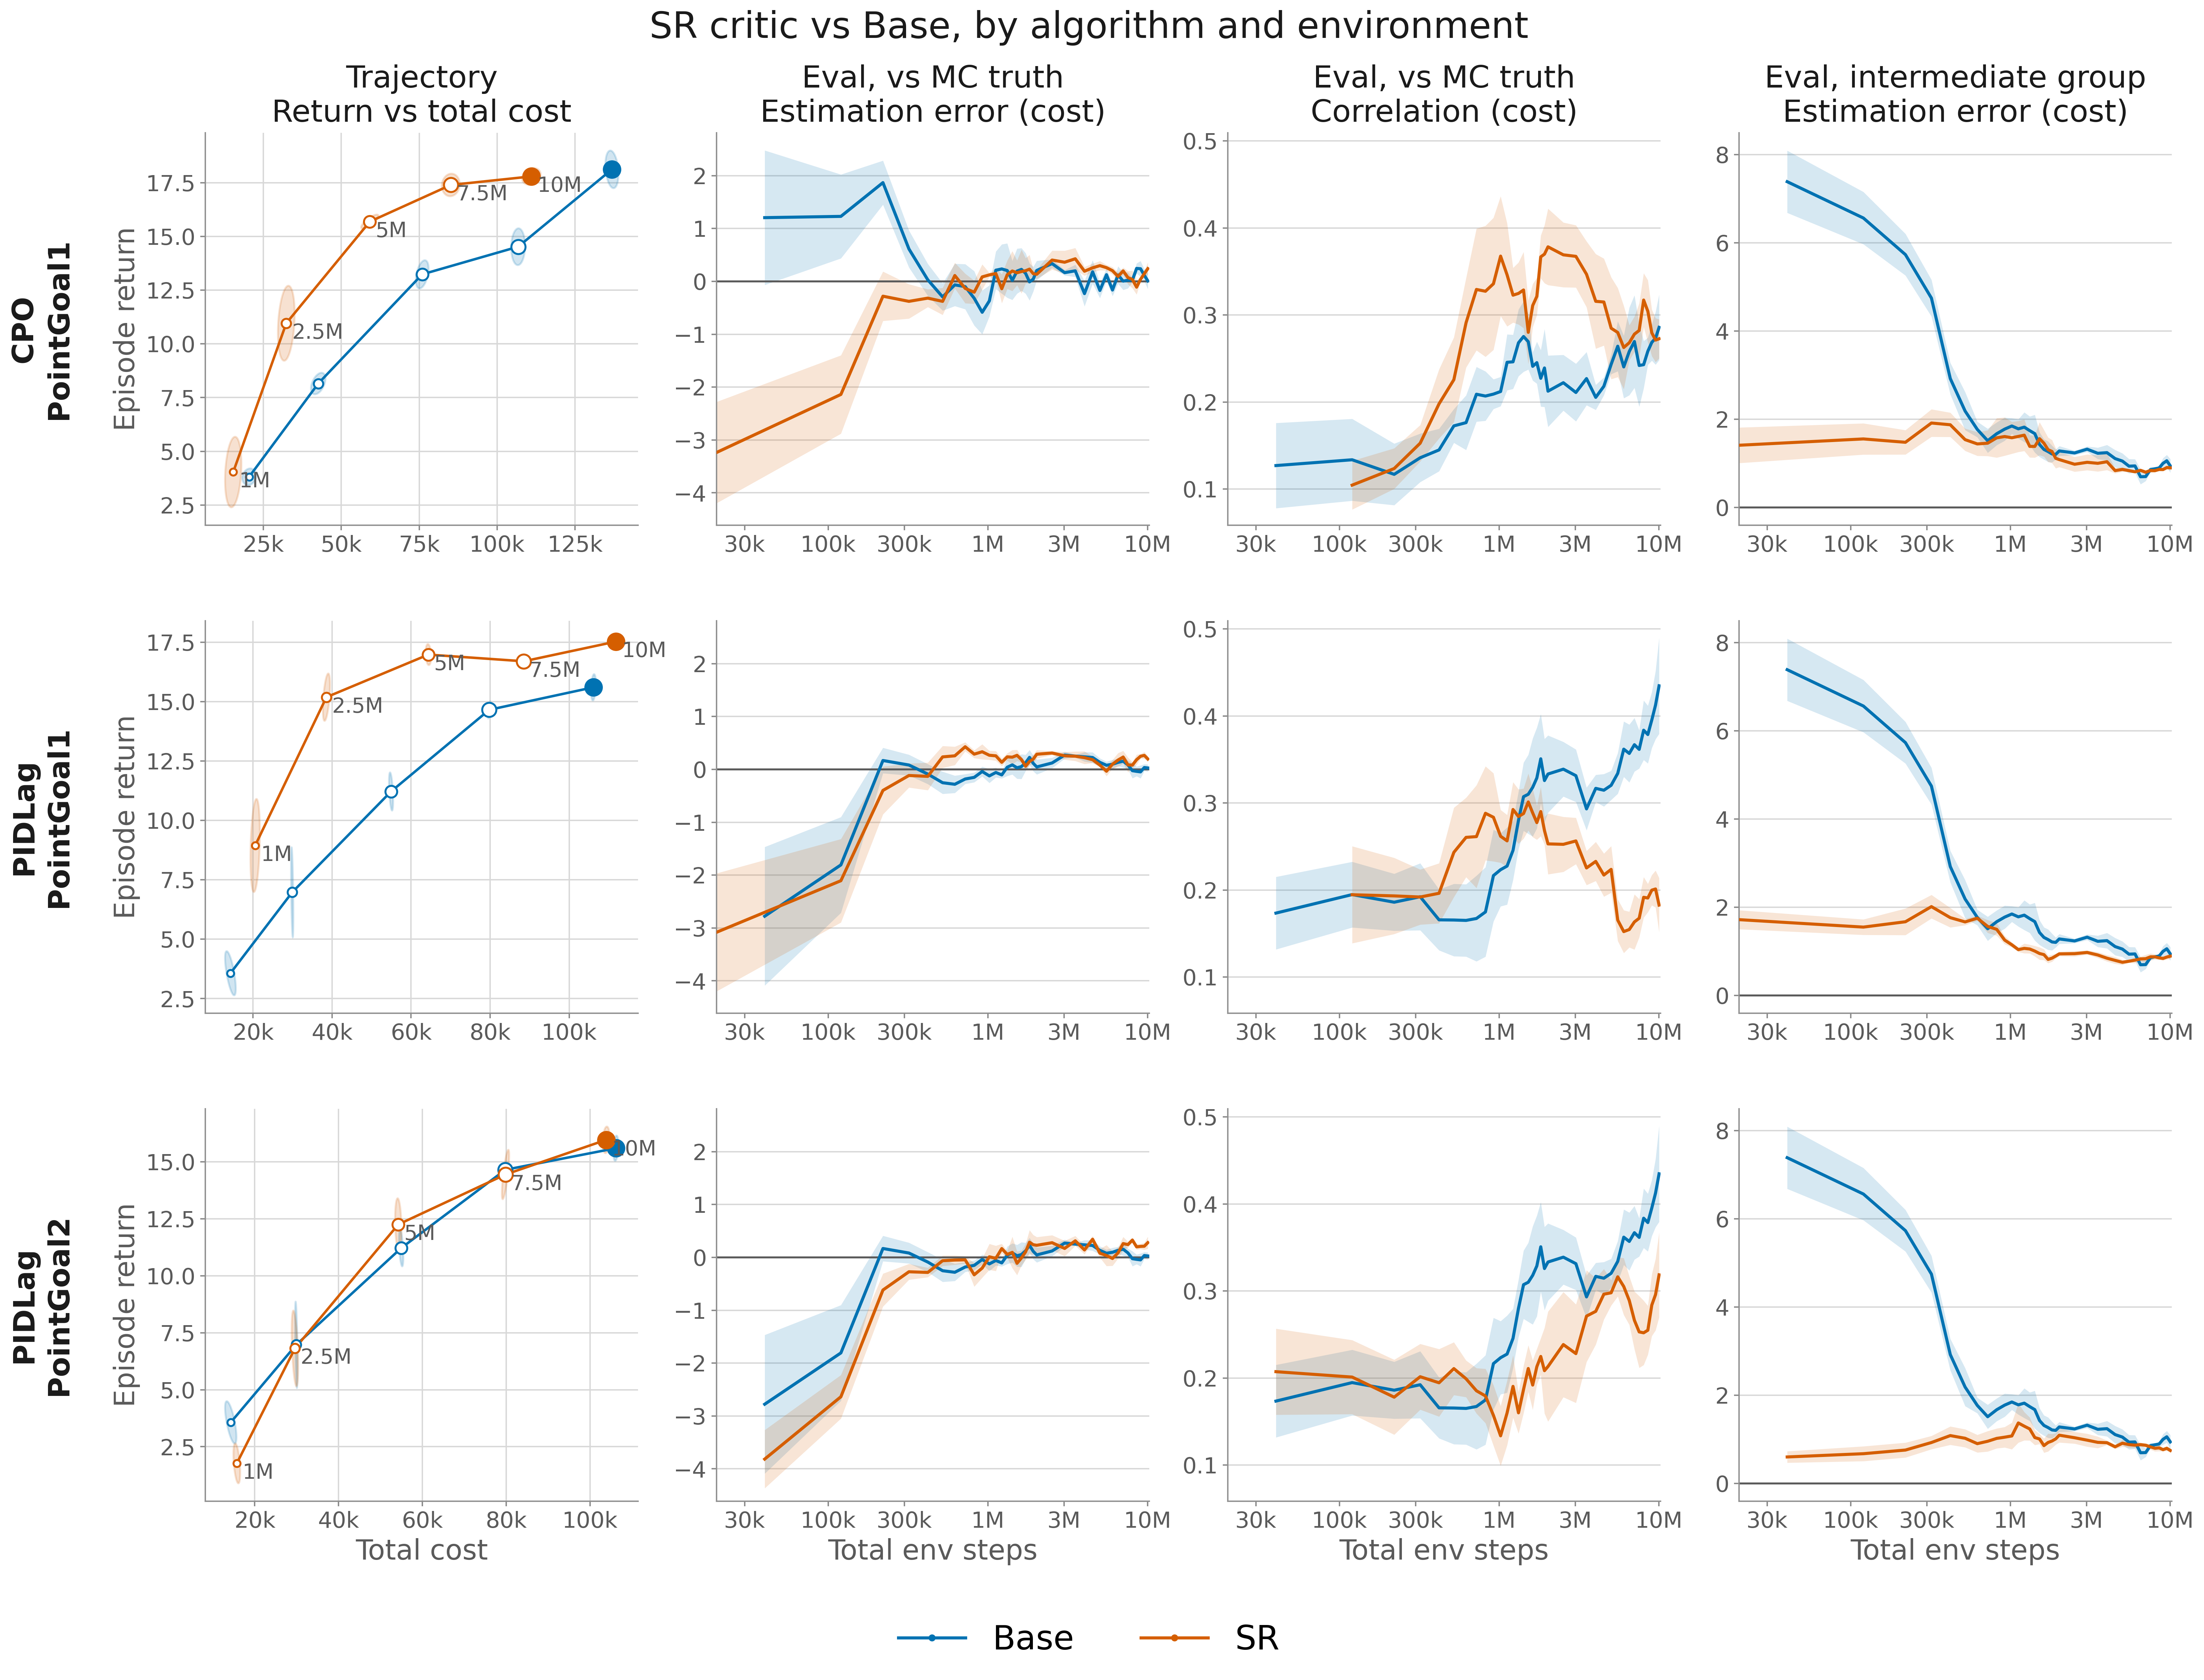

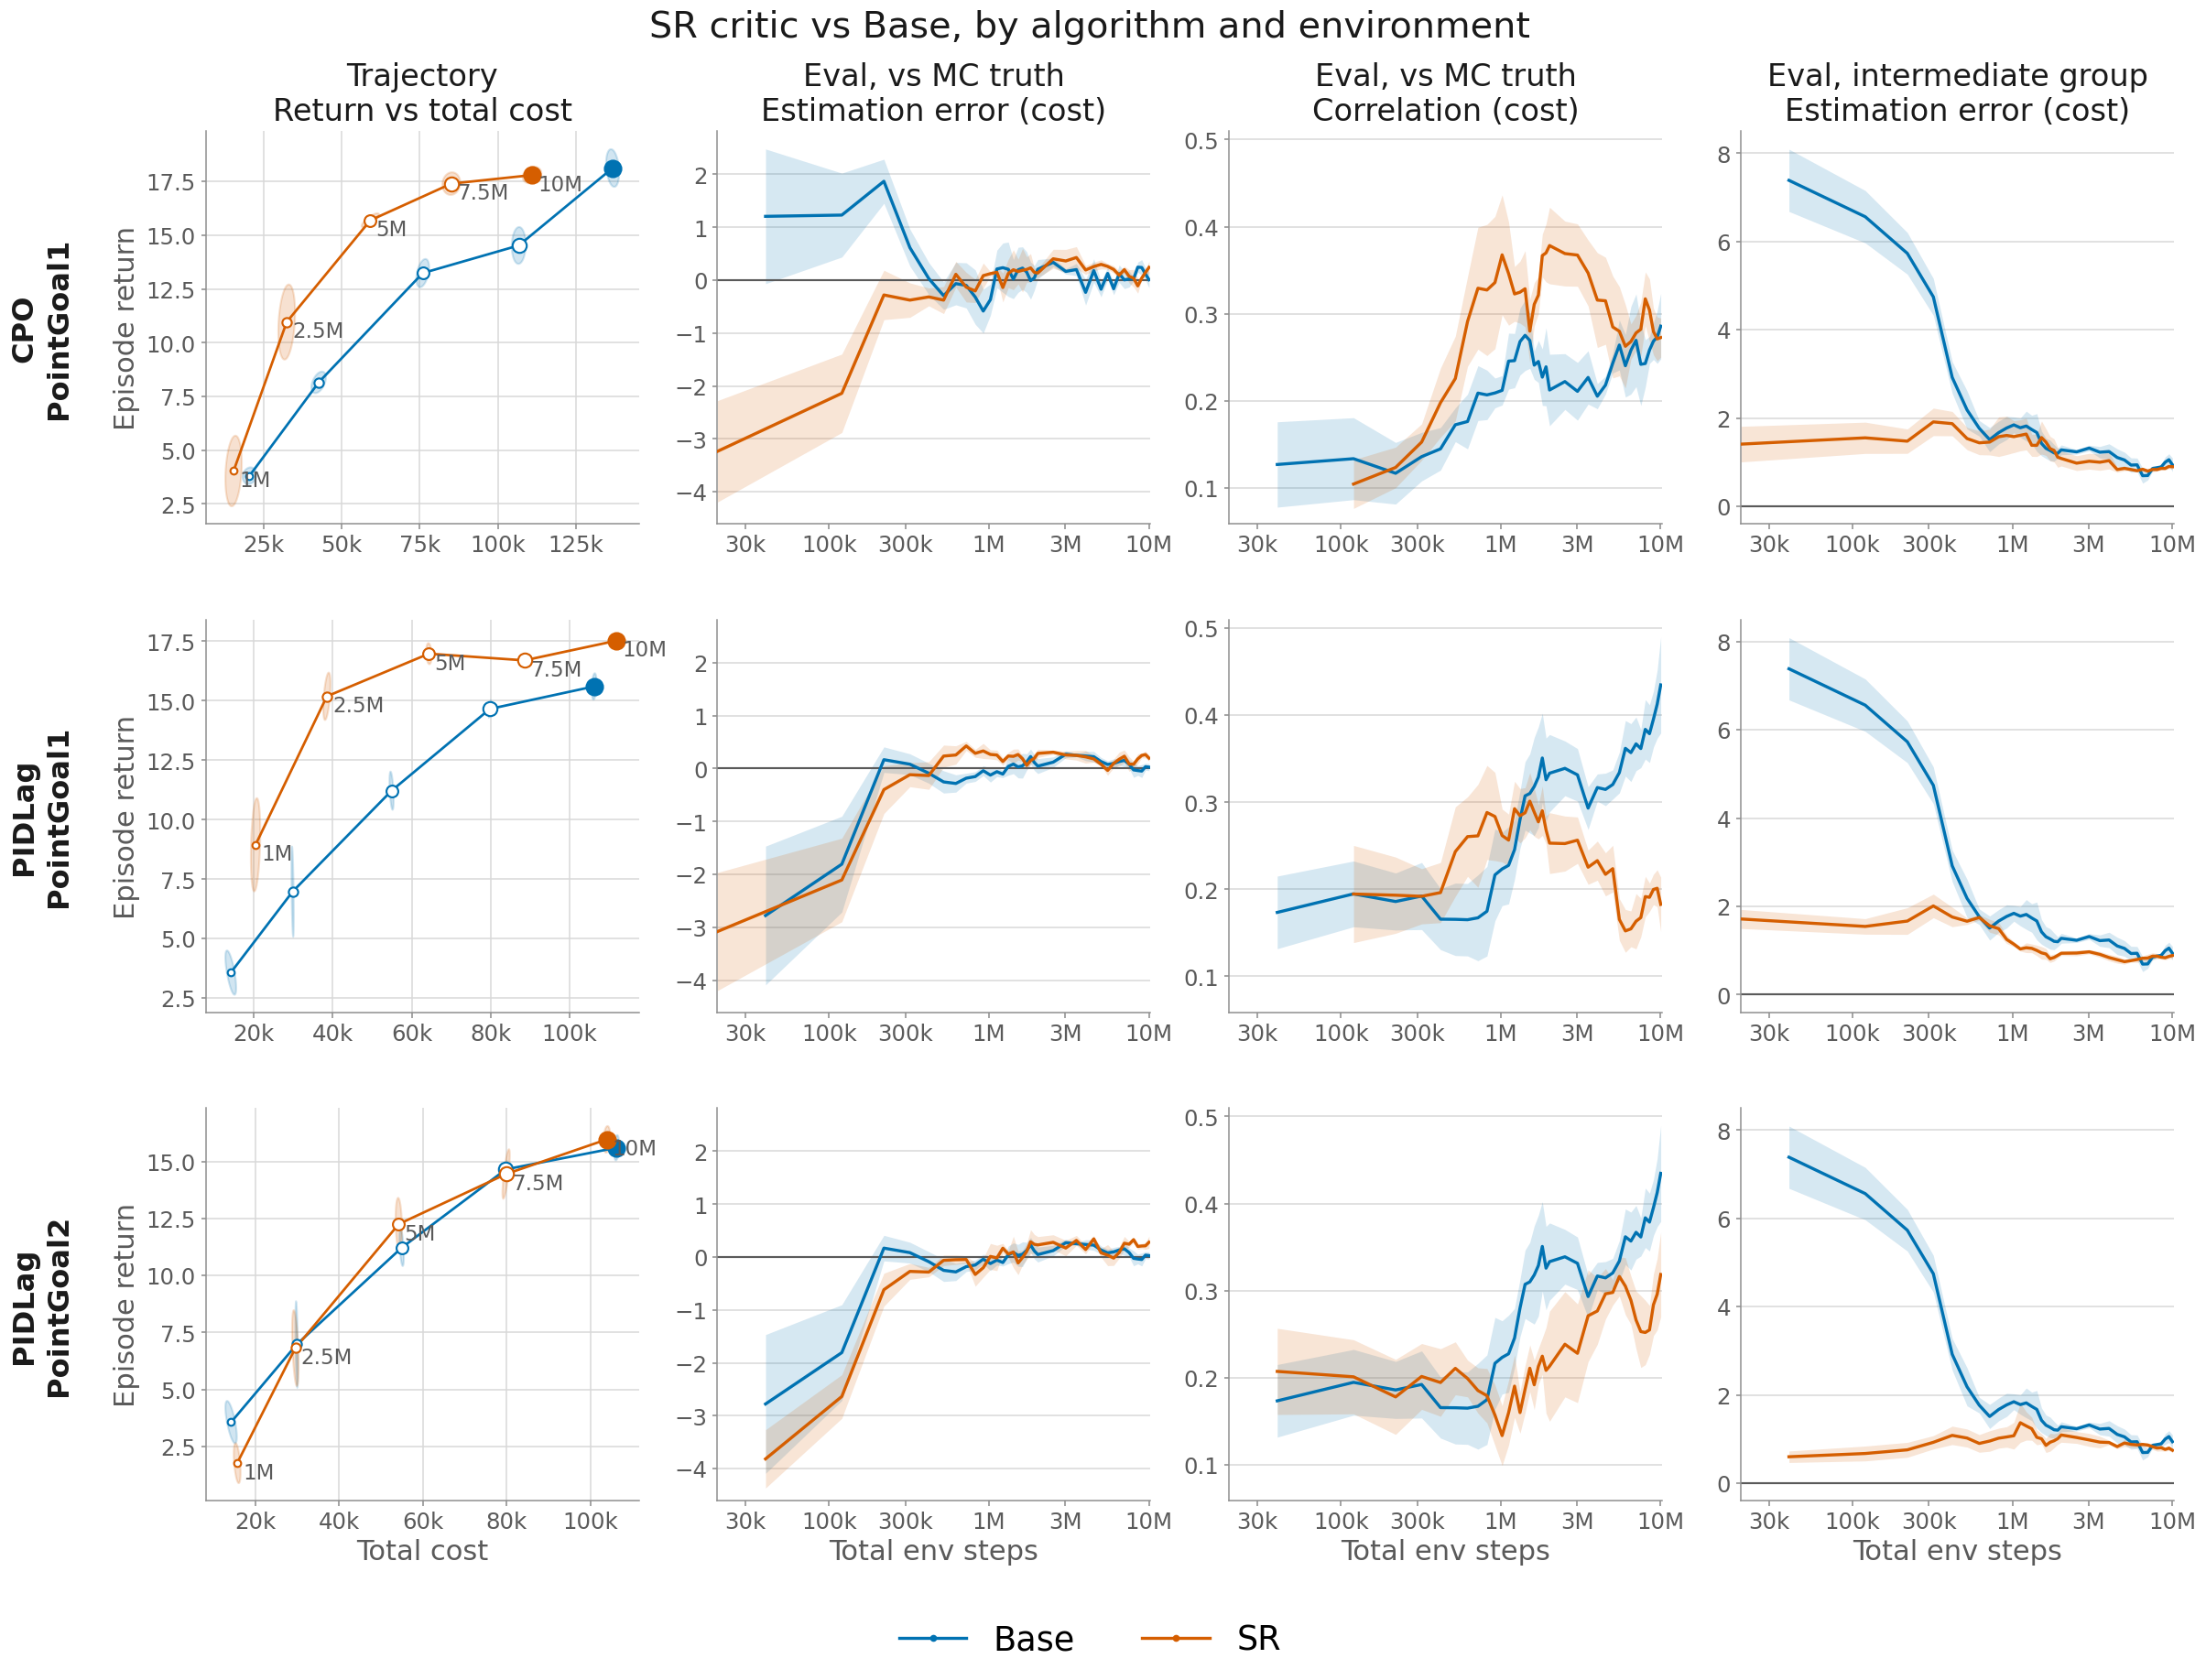

In [8]:
FIG = {
    "traj_smooth": 9,        # epochs, centred, on EpRet before reading a checkpoint
    "smooth_corr": 5,        # running mean, in eval checkpoints
    "smooth_err": 3,
    "corr_ylim": None,
    "err_ylim": None,
    "col4_ylim": None,
    "share_rows": True,      # columns 2-4 share a y scale down each column
    # Where columns 2-4 begin on the x axis.  "sr" defers to the SR arm, "all" keeps the
    # earliest step either arm reports, and a number pins it outright.
    "curve_start": "sr",
    "curve_start_arm": "SR",
    "legend_in": 1.05,
    "title_in": 0.95,
    "traj_label_checkpoints": True,
}


def smooth(M, w):
    """Running mean along the last axis, edge-normalised."""
    if w <= 1:
        return M
    k = np.ones(w)
    num = np.apply_along_axis(lambda v: np.convolve(v, k, "same"), -1, M)
    return num / np.convolve(np.ones(M.shape[-1]), k, "same")


def seed_curves(key, col):
    """(steps, per-seed matrix) for one history column, NaNs dropped first.

    The PooledMC columns are logged only at eval epochs, so a run's column is mostly NaN;
    dropping those rows before aligning keeps the curve intact, where carrying them through
    any windowed operation would erase it.
    """
    h = HIST[key]
    ids = set(RUNS[key].run_id)
    h = h[h.run_id.isin(ids)].dropna(subset=[col, "TotalEnvSteps"])
    per = [g.sort_values("TotalEnvSteps") for _, g in h.groupby("run_id")]
    per = [g for g in per if len(g)]
    if not per:
        return np.array([]), np.zeros((0, 0))
    steps = np.array(sorted(set.intersection(*[set(g.TotalEnvSteps) for g in per])))
    M = np.stack([np.interp(steps, g.TotalEnvSteps, g[col]) for g in per])
    return steps, M


def trajectory(key, steps=None, smooth_w=None):
    """Seed-mean (total cost, return) at each checkpoint, with the per-seed values behind it.

    Each seed is read at the logged epoch nearest the checkpoint; return is smoothed per seed
    first, cost is cumulative and taken as logged.
    """
    steps = list(steps or CHECKPOINTS)
    w = FIG["traj_smooth"] if smooth_w is None else smooth_w
    h = HIST[key]
    ids = set(RUNS[key].run_id)
    h = h[h.run_id.isin(ids)].dropna(subset=["TotalEnvSteps", "Metrics/EpRet",
                                             "Metrics/TotalCost"])
    per = []
    for rid, g in h.groupby("run_id"):
        g = g.sort_values("TotalEnvSteps")
        x = g.TotalEnvSteps.to_numpy(float)
        if not len(x):
            continue
        ret = g["Metrics/EpRet"].rolling(w, center=True, min_periods=1).mean().to_numpy()
        cost = g["Metrics/TotalCost"].to_numpy(float)
        idx = [int(np.abs(x - s).argmin()) for s in steps]
        per.append(pd.DataFrame({"run_id": rid, "step": steps,
                                 "cost": cost[idx], "ret": ret[idx]}))
    if not per:
        return pd.DataFrame(columns=["step", "cost", "ret", "cost_seeds", "ret_seeds"])
    d = pd.concat(per, ignore_index=True)
    out = (d.groupby("step").agg(cost=("cost", "mean"), ret=("ret", "mean"))
           .reset_index().sort_values("step"))
    out["cost_seeds"] = [d.loc[d.step == s, "cost"].to_numpy() for s in out.step]
    out["ret_seeds"] = [d.loc[d.step == s, "ret"].to_numpy() for s in out.step]
    return out


def draw_trajectory(ax, key, color, label_points=False, ls="-"):
    """One arm's path through (total cost, return), markers growing with training."""
    L = STYLE["line"]
    t = trajectory(key)
    if t.empty:
        return
    ax.plot(t.cost, t.ret, color=color, lw=L["traj_width"], ls=ls, zorder=4)
    n = len(t)
    for k, r in enumerate(t.itertuples(index=False)):
        sem_ellipse(ax, r.cost_seeds, r.ret_seeds, color)
        ax.plot(r.cost, r.ret, marker="o", color=color, zorder=5,
                ms=L["traj_marker"] + L["traj_marker_grow"] * k,
                mfc=color if k == n - 1 else "white", mew=1.4)
        if label_points:
            ax.annotate(f"{r.step/1e6:g}M", (r.cost, r.ret), xytext=(4, -11),
                        textcoords="offset points", fontsize=STYLE["font"]["note"],
                        color=STYLE["ink"]["label"], zorder=6)


def curve_start(spec, metric):
    """Where columns 2-4 should begin on the x axis.

    The SR arm reports some diagnostics later than Base -- its cost correlation only
    appears once the representation has been fitted -- so opening the panel at the
    earliest step either arm reports leaves a stretch with Base alone and nothing to
    compare it against.  "sr" defers to that arm, taking the *latest* first step among
    the columns actually drawn so no diagnostic panel opens on a single arm.
    """
    mode = FIG["curve_start"]
    if isinstance(mode, (int, float)) and not isinstance(mode, bool):
        return float(mode)
    if mode == "all":
        return X_FIRST
    if mode != "sr":
        raise ValueError('FIG["curve_start"] must be "sr", "all" or a step count; '
                         f"got {mode!r}")
    arm = FIG["curve_start_arm"]
    if arm not in ARMS:
        raise ValueError(f'FIG["curve_start_arm"]={arm!r} is not one of {ARMS}')
    key = (spec["label"], arm)
    firsts = []
    for col in ("PooledMC/EstimationError_c", "PooledMC/Correlation_c"):
        steps, _ = seed_curves(key, col)
        if len(steps):
            firsts.append(float(steps[0]))
    got = col4_curves(key, metric)
    if got is not None and len(got[0]):
        firsts.append(float(got[0][0]))
    return max(firsts) if firsts else X_FIRST


def col4_curves(key, metric=None):
    """(steps, per-seed matrix) for the chosen column-4 metric, or None if it cannot.

    A tree already on disk is loaded on demand, so the panel does not depend on section 6
    having been run in *this* kernel -- only on the download having happened at some
    point.  Nothing is fetched here; that stays an explicit step.
    """
    if key not in PROBE:
        _, dest = probe_dest(*key)
        seeds = [int(s) for s in RUNS[key].seed]
        ok, _ = probe_status(dest, seeds)
        if not ok:
            return None
        PROBE[key] = load_probe_tree(dest, seeds)
    p = PROBE[key]
    return p["steps"], map_checkpoints(p, COL4_FN[metric or COL4])


def figure_rows(rows=None, titles=None, stem_rows=None):
    """Draw one panel row per descriptor.

    A descriptor is {spec, col4, label}: which (algo, env) pairing supplies the data, which
    metric column 4 shows, and what the row is called.  The default is one row per ROWS
    entry at the global COL4; section 7 instead holds the pairing fixed and varies col4.
    """
    if rows is None:
        rows = [dict(spec=s, col4=COL4, label=s["label"]) for s in (stem_rows or ROWS)]
    rows = list(rows)
    titles = list(titles or (list(TEXT["titles"]) + ["\n".join(COL4_TEXT[COL4])]))
    fig, axes = make_axes(4, nrows=len(rows), legend_in=FIG["legend_in"],
                          title_in=FIG["title_in"], rowlab=True)
    ink = STYLE["ink"]

    for r, desc in enumerate(rows):
        spec, metric = desc["spec"], desc["col4"]
        ax = axes[r]
        for arm in ARMS:
            key, c = (spec["label"], arm), ACOLOR[arm]
            draw_trajectory(ax[0], key, c,
                            label_points=FIG["traj_label_checkpoints"] and arm == ARMS[-1])
            steps, M = seed_curves(key, "PooledMC/EstimationError_c")
            if len(steps):                       # logged as mean(true - pred); negate
                band(ax[1], steps, smooth(-M, FIG["smooth_err"]), c)
            steps, M = seed_curves(key, "PooledMC/Correlation_c")
            if len(steps):
                band(ax[2], steps, smooth(M, FIG["smooth_corr"]), c)
            got = col4_curves(key, metric)
            if got is not None and len(got[0]):
                band(ax[3], got[0], smooth(got[1], FIG["smooth_corr"]), c)

        ax[0].grid(True, axis="both", color=ink["grid"], lw=STYLE["line"]["grid"])
        ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
        ax[0].set_ylabel(TEXT["traj_y"])
        ax[1].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
        metric_rule(ax[3], metric)
        for a in ax[1:]:
            log_steps(a, curve_start(spec, metric), X_LAST,
                      xlabel=(r == len(rows) - 1))
        if r == len(rows) - 1:
            ax[0].set_xlabel(TEXT["traj_x"])
        if FIG["corr_ylim"]:
            ax[2].set_ylim(*FIG["corr_ylim"])
        if FIG["err_ylim"]:
            ax[1].set_ylim(*FIG["err_ylim"])
        if FIG["col4_ylim"]:
            ax[3].set_ylim(*FIG["col4_ylim"])
        # the zero rule is a line too, so test for plotted data rather than emptiness
        if col4_curves((spec["label"], ARMS[0]), metric) is None:
            ax[3].text(0.5, 0.5, "probes not downloaded\n(run section 6)", ha="center",
                       va="center", transform=ax[3].transAxes, style="italic",
                       fontsize=STYLE["font"]["note"], color=ink["label"])
        if r == 0:
            for a, t in zip(ax, titles):
                a.set_title(t)
        row_label(fig, ax[0], desc["label"].replace(" · ", "\n"))

    # columns 2-3 always show the same quantity down the figure; column 4 only does when
    # every row uses the same metric, which the section-7 figure deliberately does not.
    same_metric = len({d["col4"] for d in rows}) == 1
    if FIG["share_rows"] and len(rows) > 1:
        for j in ((1, 2, 3) if same_metric else (1, 2)):
            lims = [axes[r][j].get_ylim() for r in range(len(rows))]
            lo, hi = min(l for l, _ in lims), max(h for _, h in lims)
            for r in range(len(rows)):
                axes[r][j].set_ylim(lo, hi)

    for r in range(len(rows)):
        for a in axes[r]:
            thin_tick_labels(fig, a)
    legend_below(fig, [(line_key(ACOLOR[a], marker="o"), a) for a in ARMS], ncol=2)
    suptitle(fig, TEXT["suptitle"])
    return fig


save(figure_rows(), "fig6_sr_vs_base")
show("fig6_sr_vs_base")

## 6. Column 4 — the probes

Column 4's three options are all computed from the raw `eval_data` probes, which are not in
any cache until this section puts them there: **about 330 MB per row** (two arms x five seeds
x ~37 checkpoints). That is why it is a separate, per-row step rather than part of section 4.

`load_col4(row_label)` fetches and loads one row; re-running section 5 afterwards fills that
row's fourth panel. The tree is verified per seed, so an interrupted download raises rather
than silently shortening a curve.

  CPO · PointGoal1 / Base: 5 seeds x 37 checkpoints


  CPO · PointGoal1 / SR: 5 seeds x 37 checkpoints
  PIDLag · PointGoal1 / Base: 5 seeds x 37 checkpoints
  PIDLag · PointGoal1 / SR: 5 seeds x 37 checkpoints
  PIDLag · PointGoal2 / Base: 5 seeds x 37 checkpoints
  PIDLag · PointGoal2 / SR: 5 seeds x 37 checkpoints
saved: fig6_sr_vs_base png/pdf


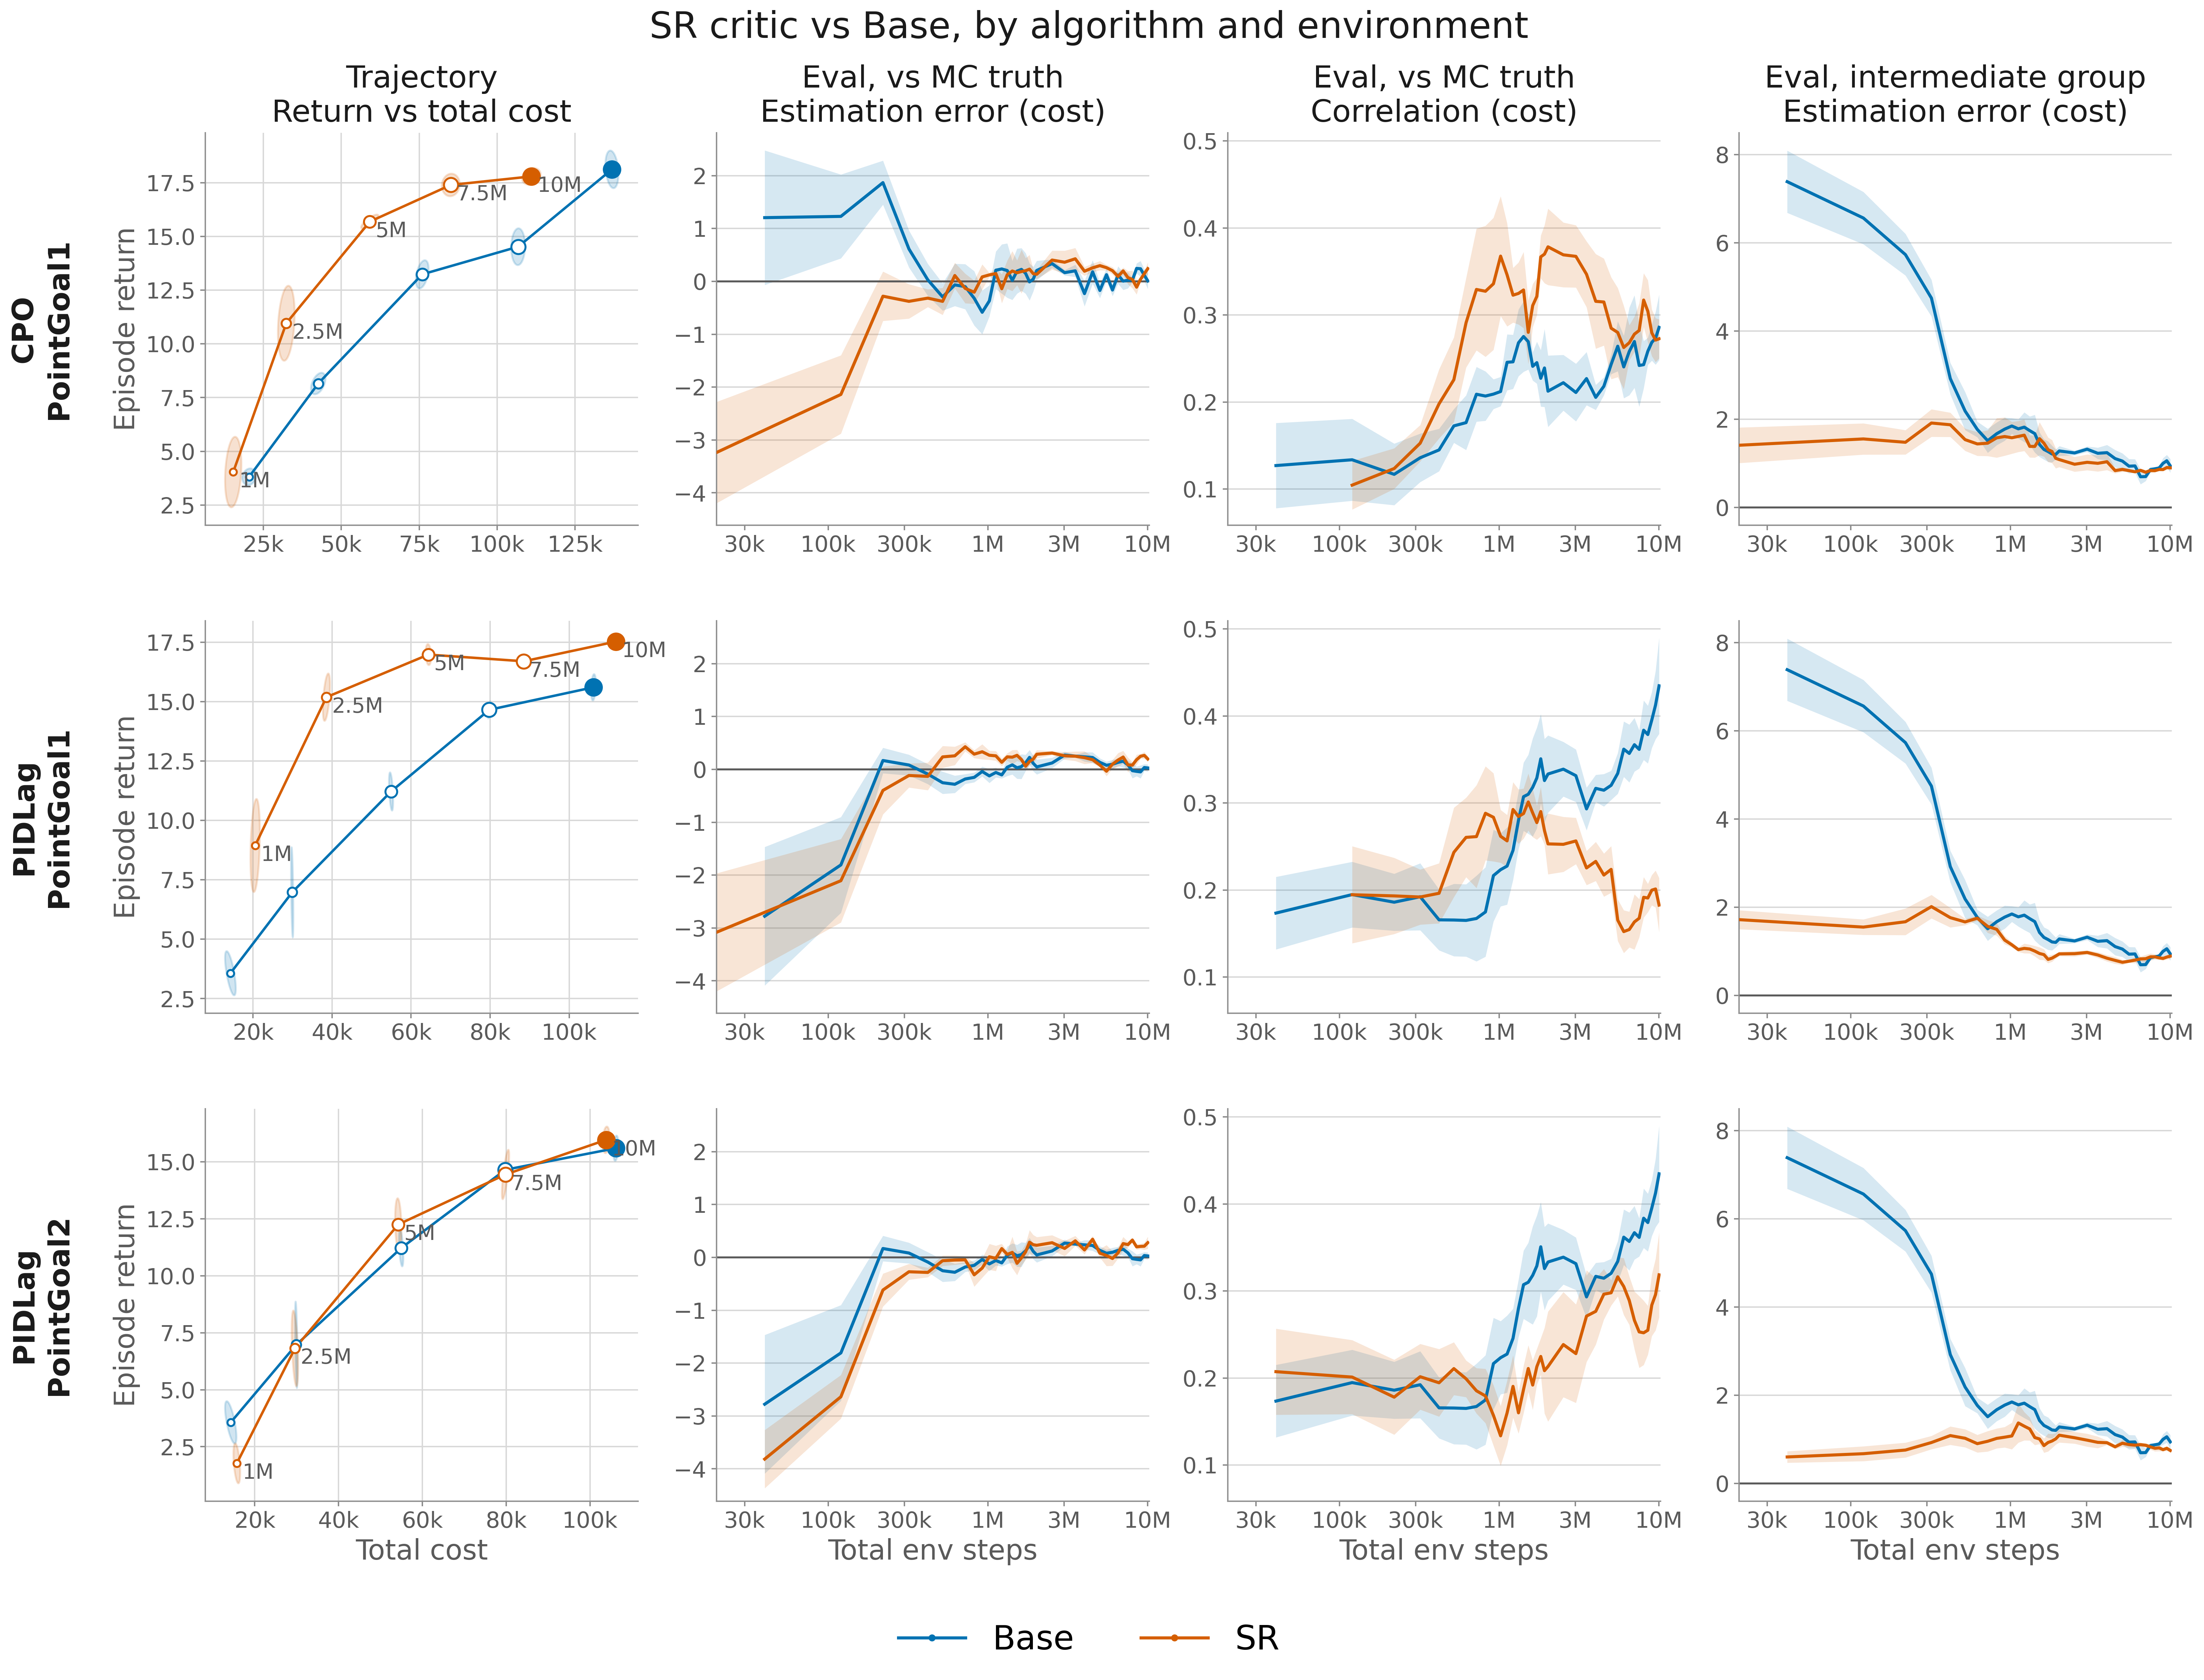

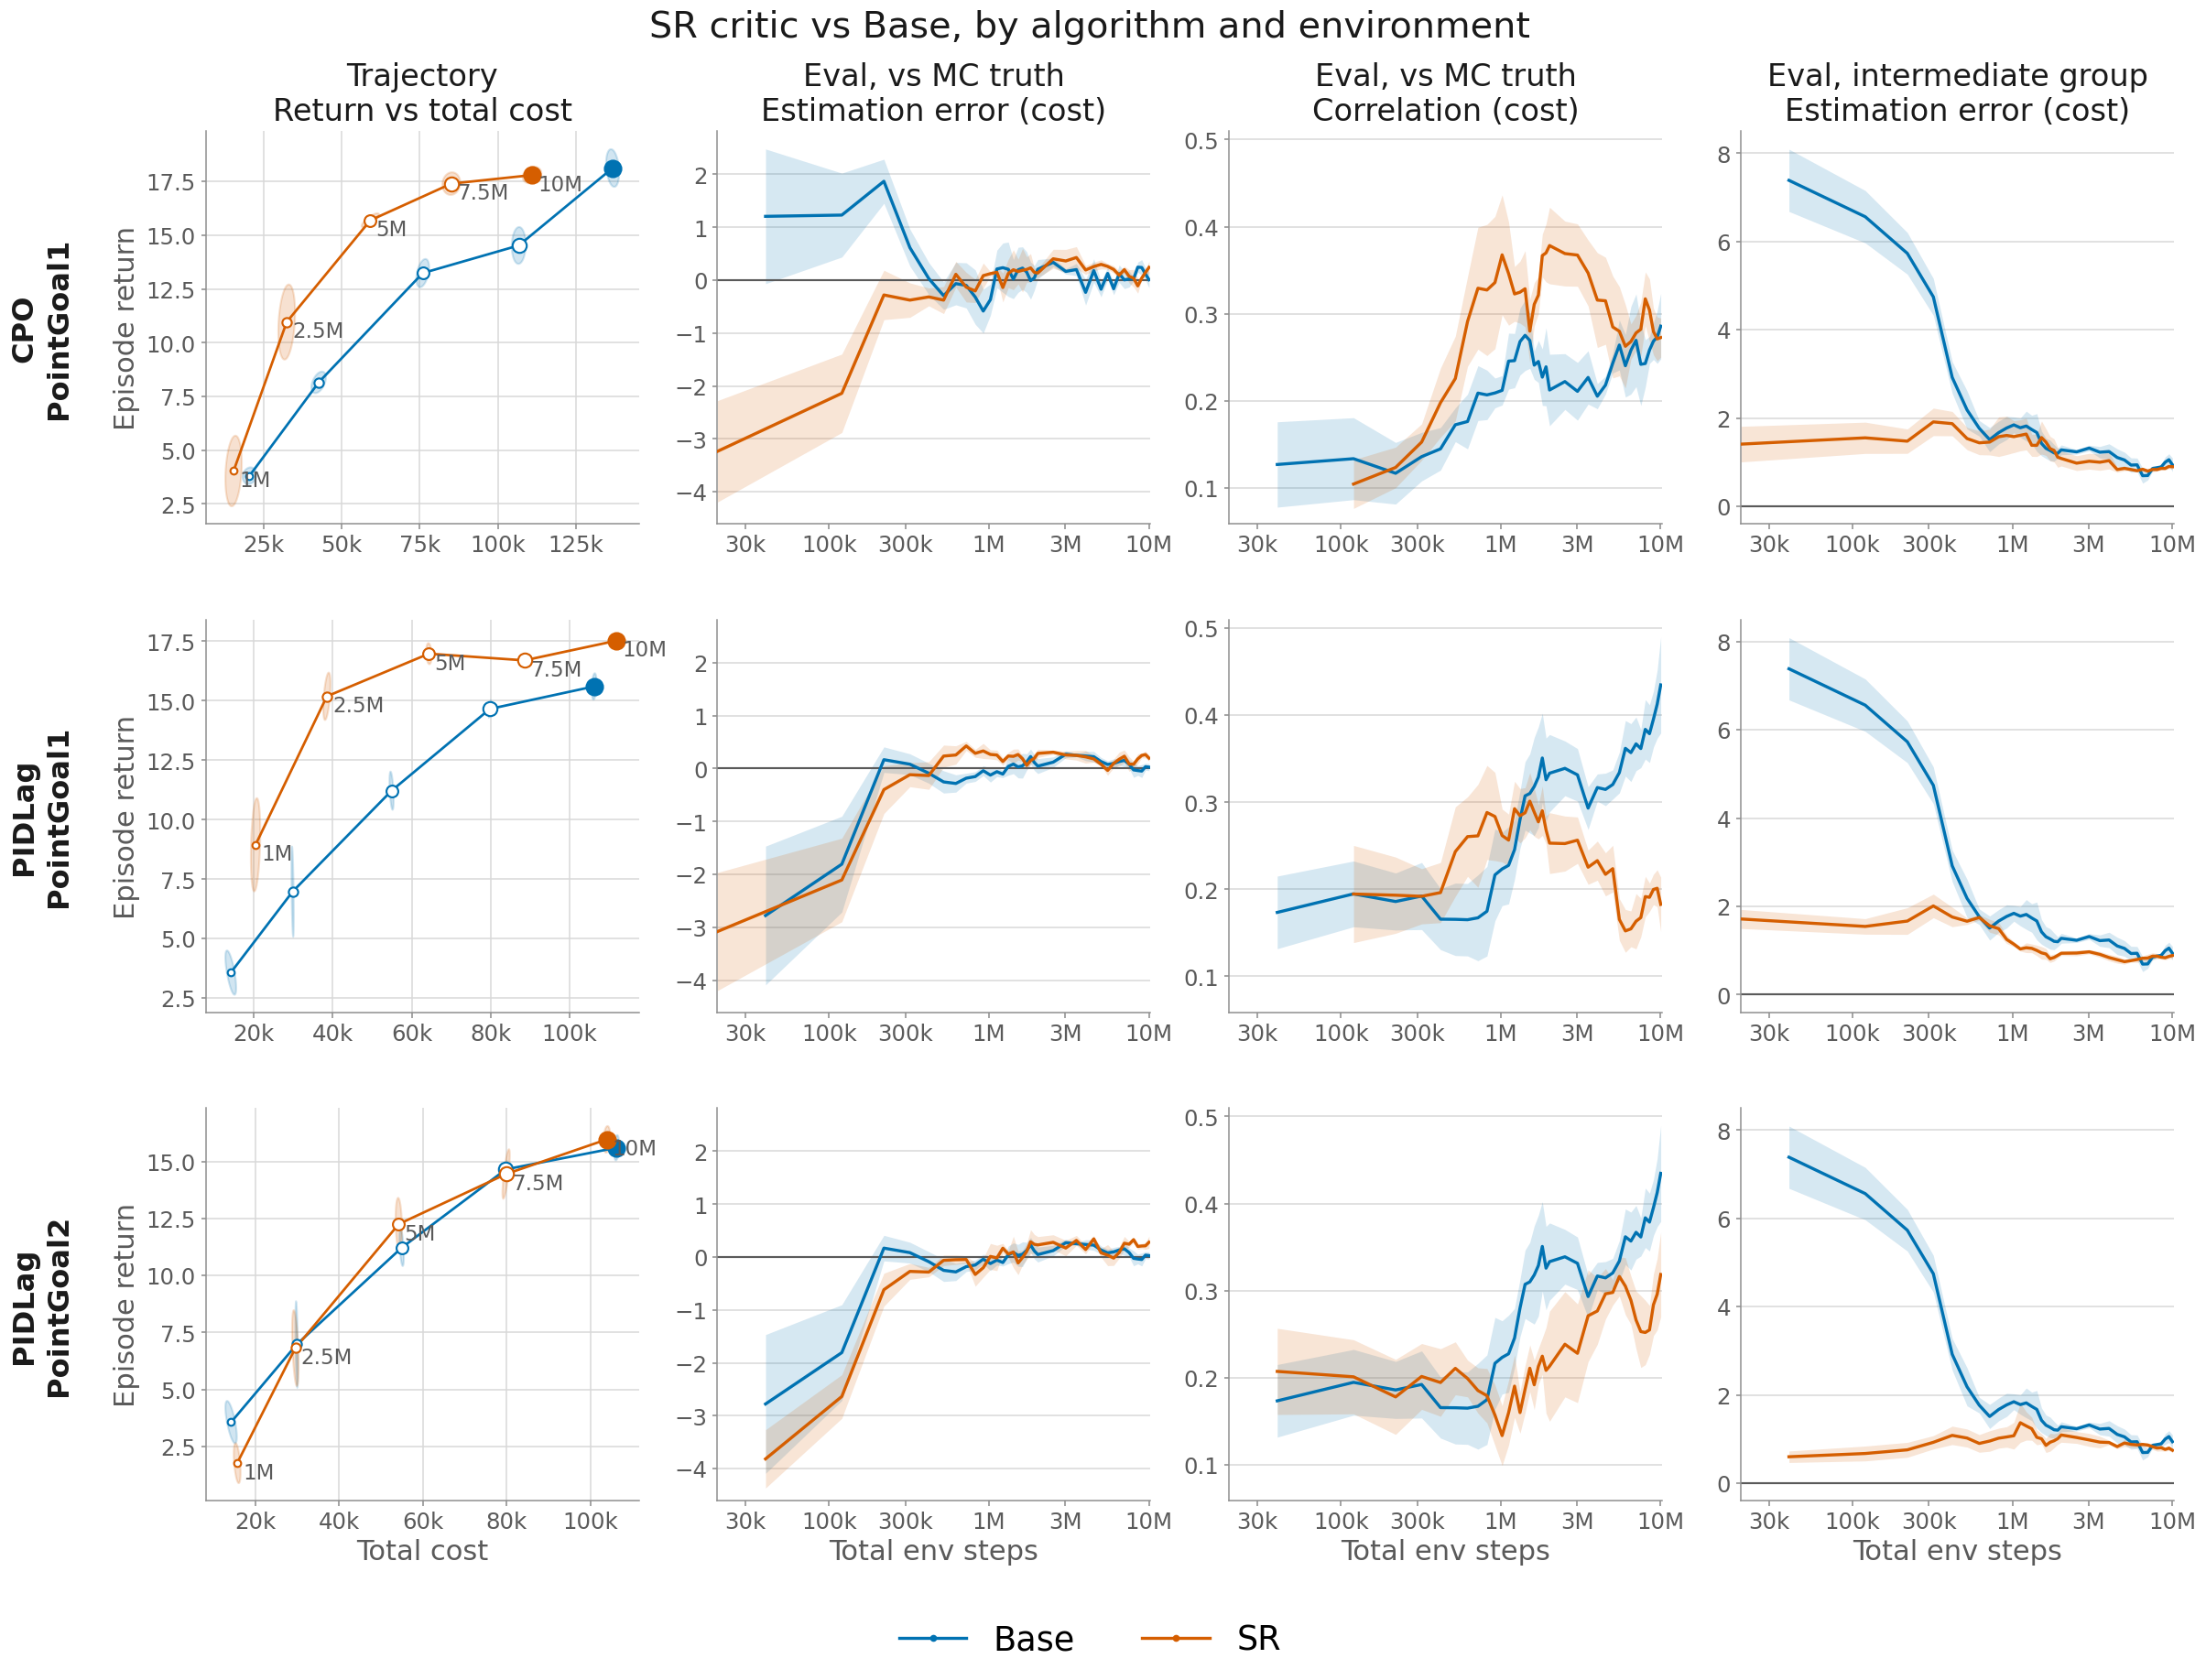

In [9]:
def load_col4(row_label, spe=20_000):
    """Fetch (if needed) and load the probes for one row, both arms."""
    for arm in ARMS:
        key = (row_label, arm)
        runs = RUNS[key]
        seeds = [int(s) for s in runs.seed]
        _, dest = probe_dest(row_label, arm)
        ok, detail = probe_status(dest, seeds)
        if not ok:
            print(f"  {row_label} / {arm}: {detail}; downloading -> {dest.name}")
            download_probes(dict(zip(seeds, runs.run_id)), dest)
            ok, detail = probe_status(dest, seeds)
            if not ok:
                raise RuntimeError(f"{row_label}/{arm}: probes still incomplete -- {detail}")
        print(f"  {row_label} / {arm}: {detail}")
        PROBE[key] = load_probe_tree(dest, seeds, spe=spe)
    return {a: PROBE[(row_label, a)] for a in ARMS}


# One download per row, cached after the first run.  Trim this list to load fewer.
for spec in ROWS:
    load_col4(spec["label"])

# redraw now that column 4 has something to show
save(figure_rows(), "fig6_sr_vs_base")
show("fig6_sr_vs_base")

## 7. One pairing, every metric

The same four columns as section 5, but holding the **Base/SR pairing fixed** and putting
*every* column-4 metric on its own row. Columns 1–3 are therefore identical down the figure —
the trajectory, estimation error and cost correlation of that one pairing — and only the
fourth column changes. That repetition is the point: each metric is read against the same
context without flipping between figures.

`METRIC_FIG["row"]` chooses the pairing by its `ROWS` label (`None` takes the first). To
compare a Base/SR pair that is not in `ROWS` yet, add it there — that is the one place a
pairing is declared, and section 4 will load it.

Columns 2–3 still share a y scale down the figure, since every row draws the same quantity
there. Column 4 deliberately does **not**: AUROC, ECE and a signed error have nothing to gain
from a shared axis. This needs the row's probes, so run section 6 first.

saved: fig6_metrics_CPO_PointGoal1 png/pdf


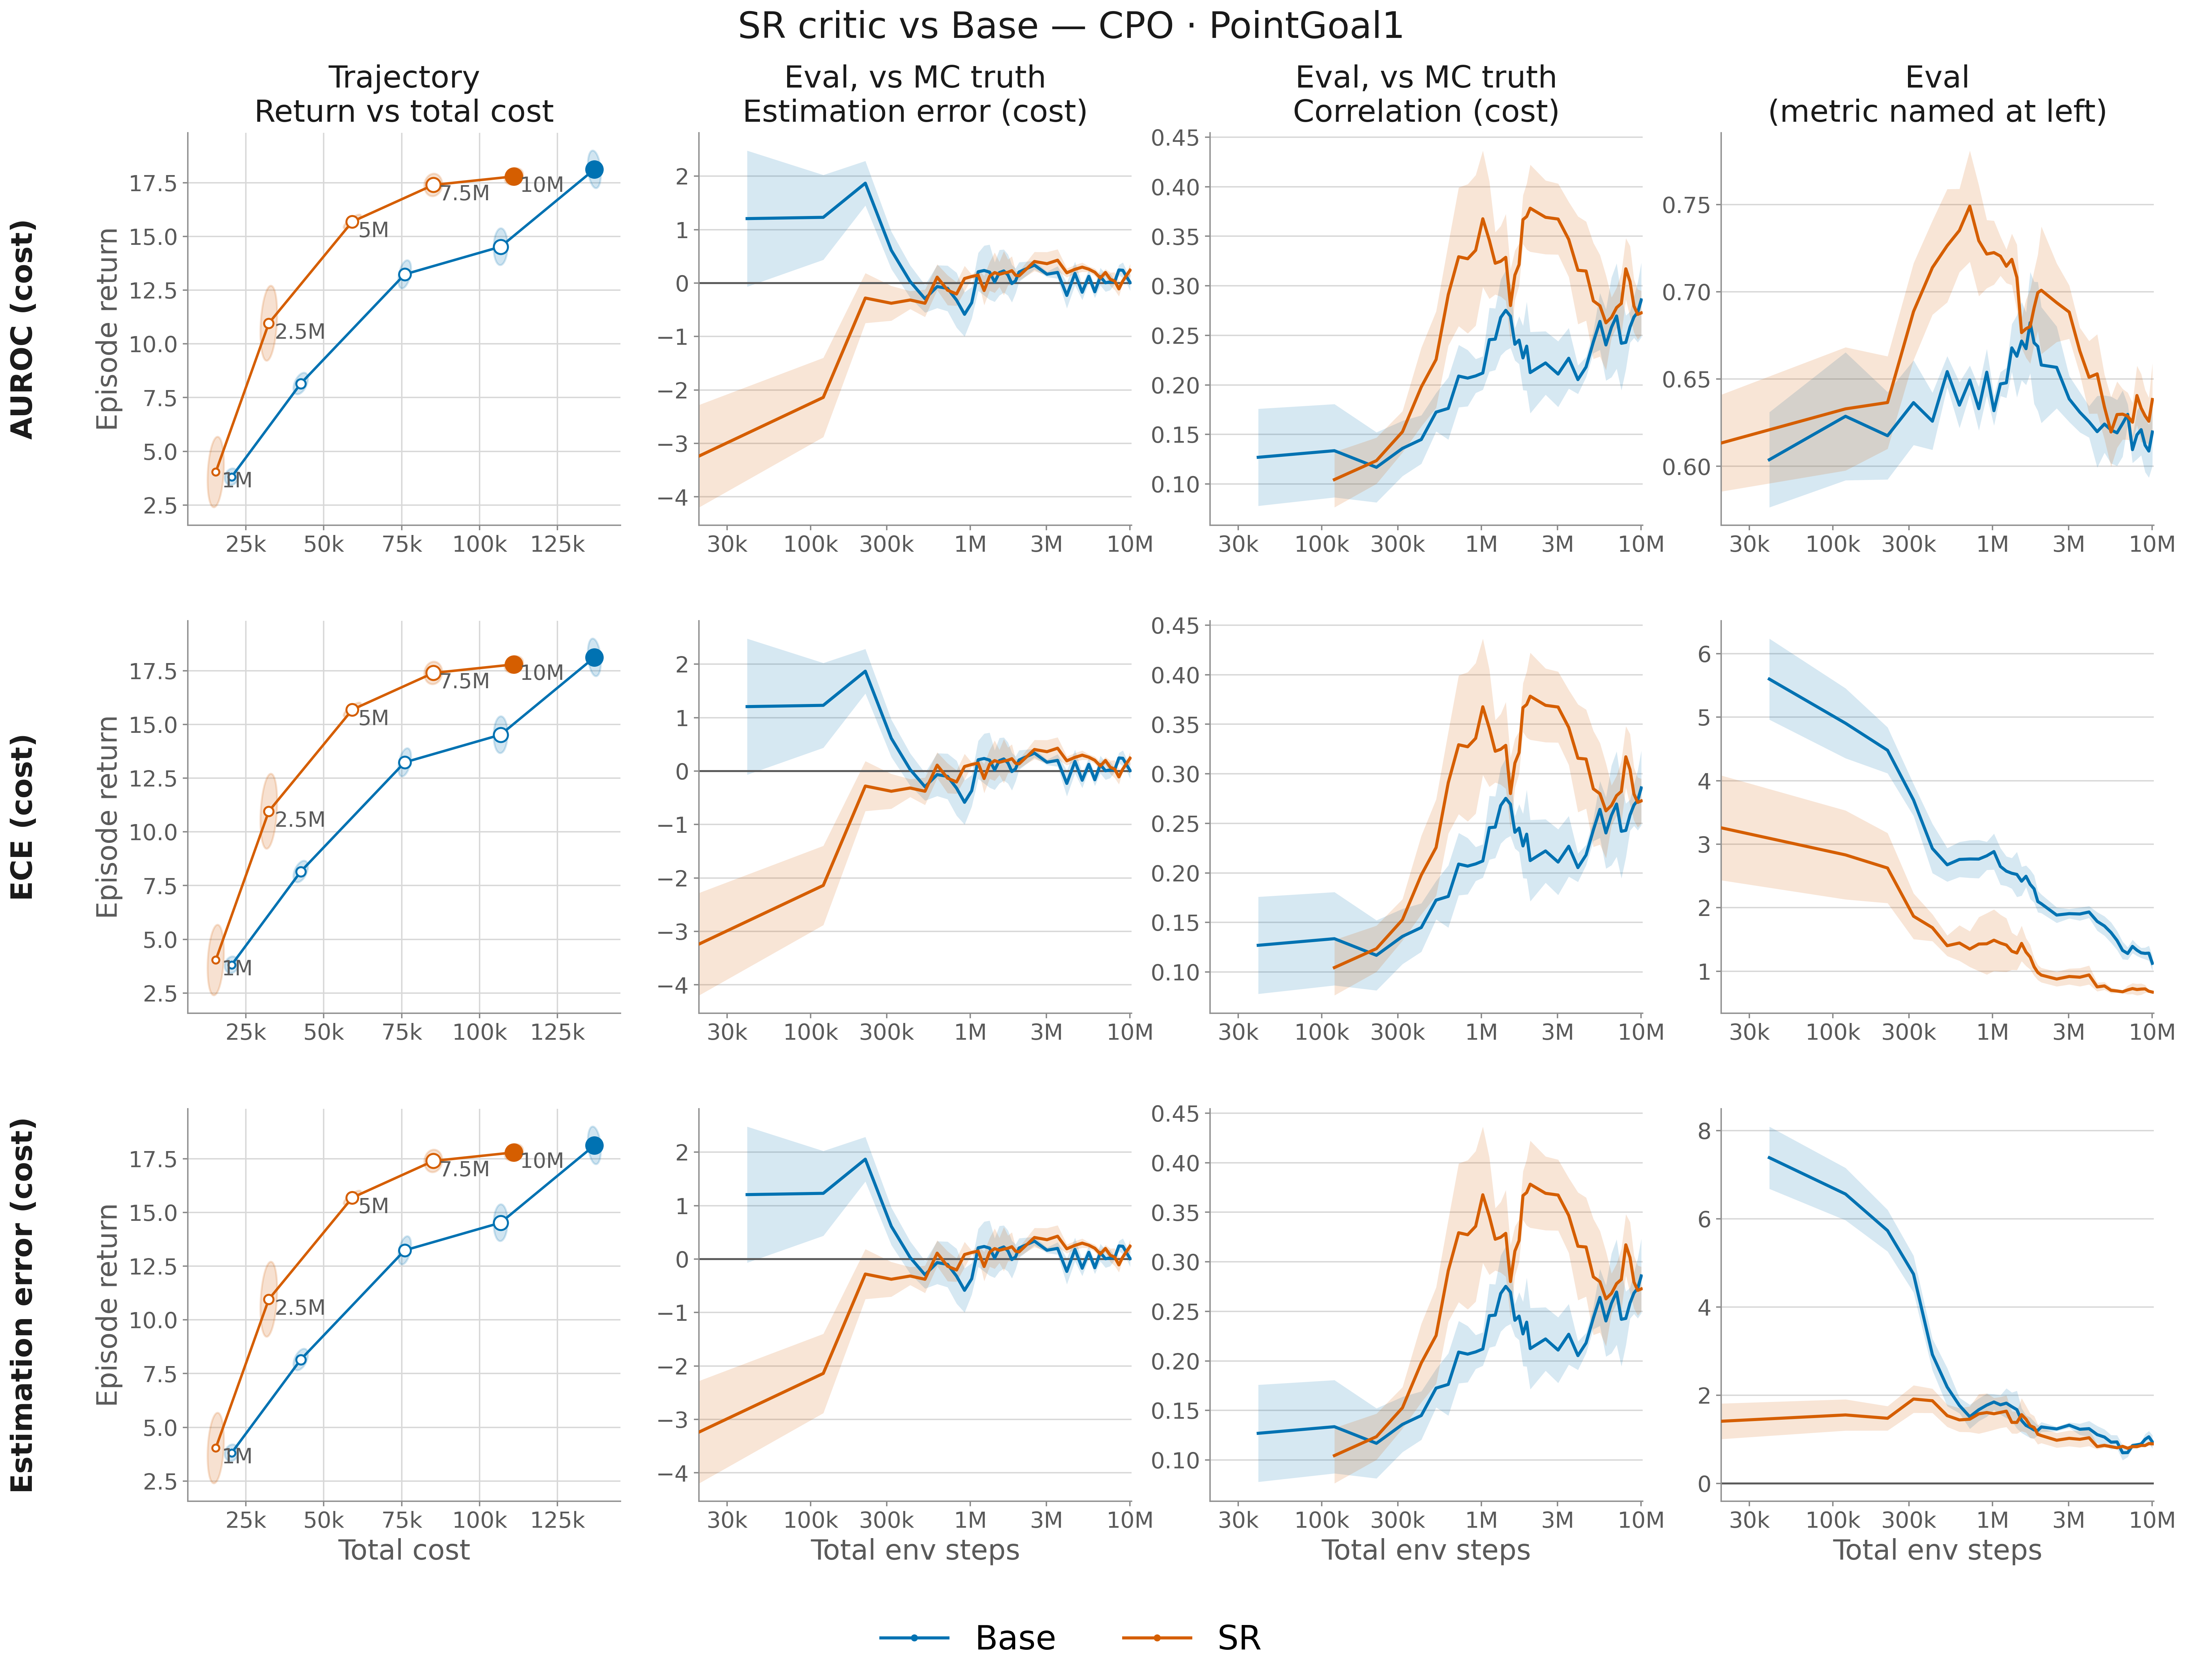

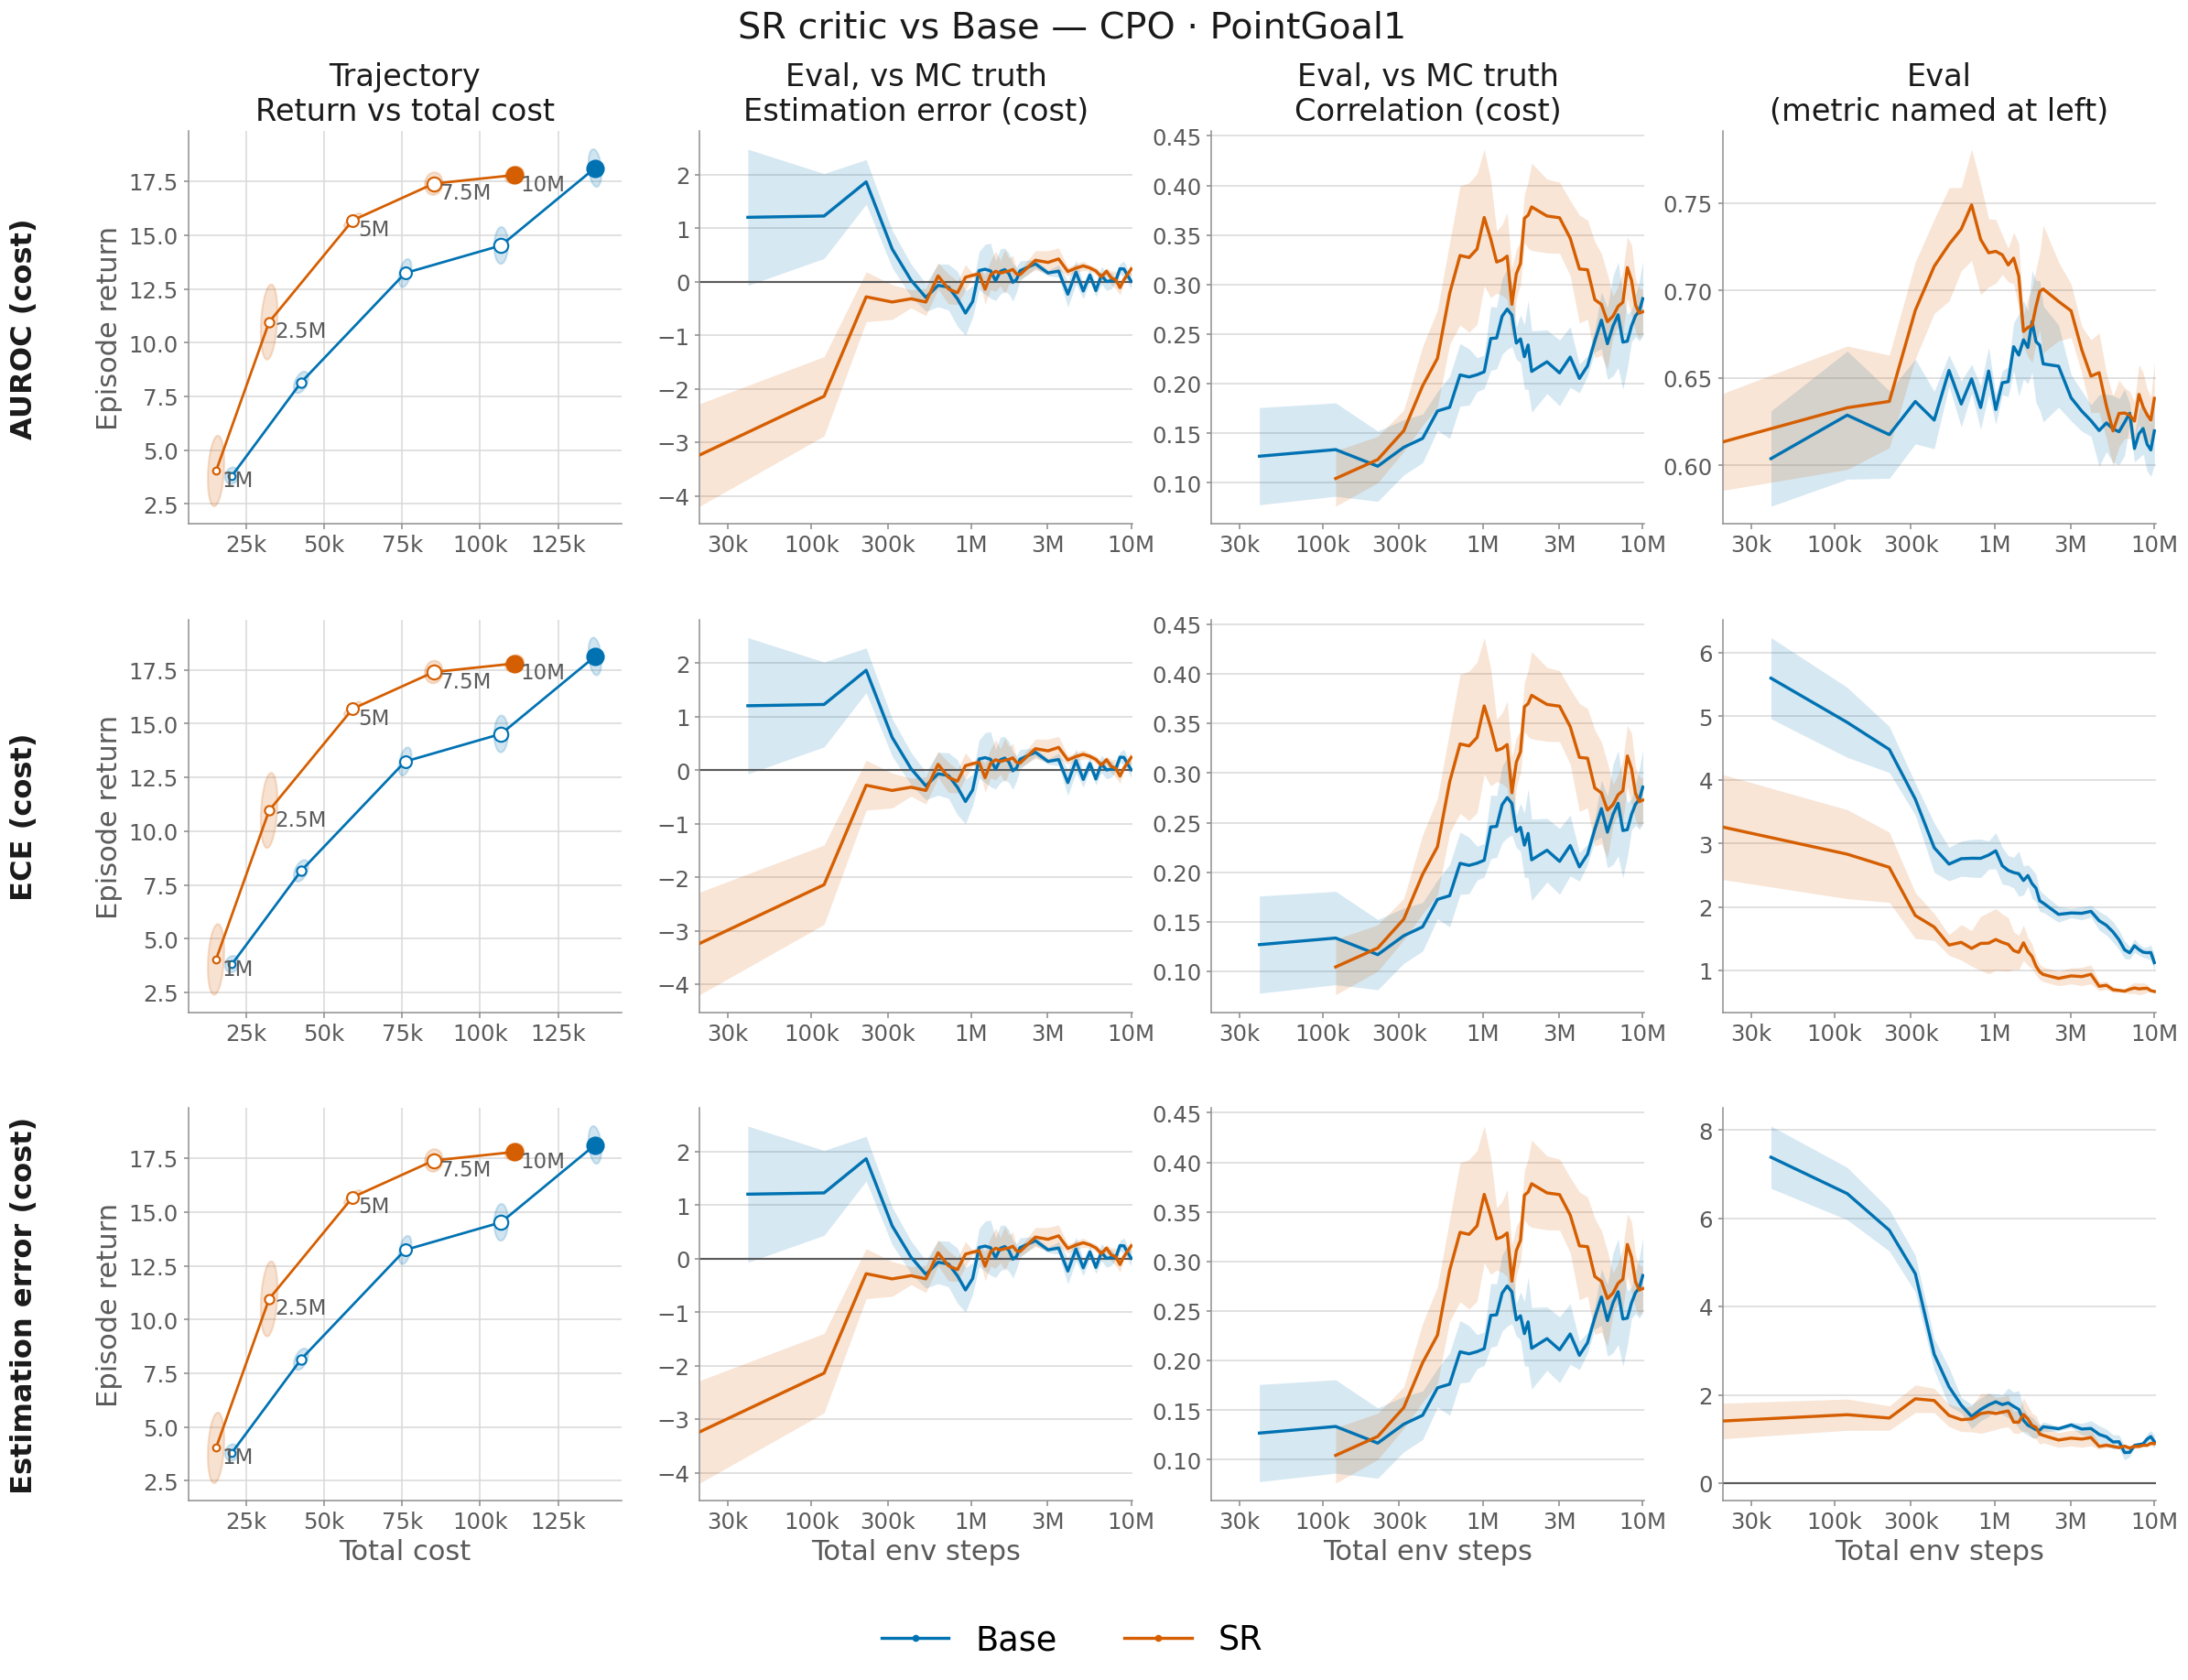

In [10]:
METRIC_FIG = {
    "row": None,          # a ROWS label, or None for the first entry
    "metrics": list(COL4_FN),          # every available column-4 metric, one per row
}


def figure_metrics(row_label=None, metrics=None):
    """One pairing, one row per column-4 metric."""
    label = row_label or METRIC_FIG["row"] or ROWS[0]["label"]
    spec = SPECS.get(label)
    if spec is None:
        raise ValueError(f"{label!r} has not been loaded; have {sorted(SPECS)}")
    mets = list(metrics or METRIC_FIG["metrics"])
    bad = [m for m in mets if m not in COL4_FN]
    if bad:
        raise ValueError(f"unknown metric(s) {bad}; have {list(COL4_FN)}")
    if any(col4_curves((label, a)) is None for a in ARMS):
        print(f"note: {label} has no probes on disk -- run section 6, or column 4 stays blank")

    rows = [dict(spec=spec, col4=m, label=COL4_LABEL[m]) for m in mets]
    titles = list(TEXT["titles"]) + [TEXT["col4_per_row"]]
    fig = figure_rows(rows, titles=titles)
    suptitle(fig, TEXT["suptitle_metrics"].format(row=label))
    return fig


metric_stem = f"fig6_metrics_{(METRIC_FIG['row'] or ROWS[0]['label'])}"
metric_stem = metric_stem.replace(" · ", "_").replace(" ", "")
save(figure_metrics(), metric_stem)
show(metric_stem)

### 7.1 PIDLag, every metric, with Base pinned to `plain`

Section 7 again, for a pairing given outright rather than taken from `ROWS`: **TRPOPID** on
`SafetyPointGoal1-v0`, Base from `hyfcu0dx` and SR from `84vmrbam`.

The Base arm is restricted to `adv-estimation-method = plain` **before scoring**, so it cannot
win on `gae` while the SR arm — whose sweep only ever ran `plain` — has no such choice. Only
Base carries the filter; pinning SR as well would be a no-op.

Because the pinned Base selects a different config out of `hyfcu0dx` than the unfiltered row
does, it gets its own history and probe caches. Its probes are therefore a separate download
from anything section 6 has already fetched; the SR arm reuses the tree it has.

In [ ]:
PIDLAG_METRICS = {
    "spec": dict(
        label="PIDLag · PointGoal1 · Base plain",
        algo="TRPOPID", env="SafetyPointGoal1-v0",
        arms={
            # only Base is pinned -- 84vmrbam ran a single estimator, so filtering it
            # would change nothing
            "Base": dict(sweep="hyfcu0dx",
                         filters={"adv-estimation-method": "plain"}),
            "SR": dict(sweep="84vmrbam"),
        },
    ),
    "metrics": list(COL4_FN),
    # The pinned Base arm has its own probe tree, which section 6 has not fetched;
    # without this column 4 stays blank.  Set False to skip the download.
    "fetch_probes": True,
}

load_row(PIDLAG_METRICS["spec"])

_lbl = PIDLAG_METRICS["spec"]["label"]
if PIDLAG_METRICS["fetch_probes"]:
    load_col4(_lbl)

pidlag_fig = figure_metrics(_lbl, PIDLAG_METRICS["metrics"])
save(pidlag_fig, "fig6_metrics_pidlag_base_plain")
show("fig6_metrics_pidlag_base_plain")

## 8. The same figure, with the advantage estimator pinned

Section 5 lets each arm win on whatever `adv-estimation-method` suits it, so a Base arm can
take `gae` while its SR counterpart is `plain` — the SR sweeps only ever ran `plain`. That
makes the comparison best-against-best but not like-for-like.

This redraws section 5 with every arm **restricted to `plain` before scoring**, so both sides
differ in the critic and nothing else. The restriction happens at selection time, not by
re-fetching: the summaries are already cached, so only the newly chosen runs' history is
pulled.

`BIASED["filters"]` is an ordinary arm filter — any config column works, and several can be
combined. A filtered arm gets its own history and probe caches, since it selects a different
config out of the same sweep; the unfiltered rows keep theirs untouched. Column 4 needs that
variant's probes, which are a separate download from section 6's.

In [ ]:
BIASED = {
    "filters": {"adv-estimation-method": "plain"},
    # Which arms to pin.  None means every arm, but not every sweep ran every estimator --
    # an SR sweep that only ever ran gae/gae-rtg cannot be pinned to plain -- so restricting
    # this to ["Base"] is often what is wanted.
    "arms": None,
    "suffix": " · plain",
}


def biased_specs(filters=None, arms=None, suffix=None):
    """ROWS again, with the named arms restricted to `filters` and the row relabelled."""
    filters = BIASED["filters"] if filters is None else filters
    arms = BIASED["arms"] if arms is None else arms
    suffix = BIASED["suffix"] if suffix is None else suffix
    pin = set(arms or ARMS)
    out = []
    for spec in ROWS:
        s = dict(spec)
        s["label"] = spec["label"] + suffix
        s["arms"] = {arm: (dict(spec["arms"][arm],
                                filters={**(spec["arms"][arm].get("filters") or {}),
                                         **filters})
                           if arm in pin else dict(spec["arms"][arm]))
                     for arm in ARMS}
        out.append(s)
    return out


bias_txt = ", ".join(f"{k.split('.')[-1]} = {v}" for k, v in BIASED["filters"].items())
print(f"re-selecting with {bias_txt} on {BIASED['arms'] or ARMS}\n")

BIAS_ROWS, bias_skipped = [], []
for _s in biased_specs():
    try:
        load_row(_s)
        BIAS_ROWS.append(_s)
    except (RuntimeError, KeyError) as exc:
        # A sweep that never ran the pinned value cannot contribute a like-for-like row.
        # Dropping it silently would misrepresent the figure, so say so and carry on.
        bias_skipped.append((_s["label"], str(exc)))

if bias_skipped:
    print("\nleft out -- the filter is not satisfiable there:")
    for _lbl, _why in bias_skipped:
        print(f"  {_lbl}: {_why}")
if not BIAS_ROWS:
    raise RuntimeError(
        f"no row could be pinned to {bias_txt}. Set BIASED['arms'] = ['Base'] to pin only "
        "the Base arm, or choose a value the sweeps actually ran.")

bias_fig = figure_rows([dict(spec=s, col4=COL4, label=s["label"]) for s in BIAS_ROWS])
suptitle(bias_fig, TEXT["suptitle_biased"].format(bias=bias_txt))
save(bias_fig, "fig6_sr_vs_base_plain")
show("fig6_sr_vs_base_plain")

## 9. Which config each arm got

The audit trail: what was picked for each arm of each row, and over how large a pool.

In [ ]:
rows = []
for spec in list(ROWS) + [s for s in SPECS.values() if s["label"] not in
                                     {r["label"] for r in ROWS}]:
    for arm in ARMS:
        key = (spec["label"], arm)
        row, keys = PICK[key]
        if (spec["label"], arm) not in PICK:
            continue
        rows.append(dict(row=spec["label"], arm=arm, sweep=spec["arms"][arm]["sweep"],
                         config=config_label(row, keys, maxn=8),
                         EpRet=round(float(row.EpRet), 2),
                         avg_ep_cost=round(float(row.avg_ep_cost), 2),
                         ratio=round(float(row.ratio), 3), n_seeds=int(row.n_seeds)))
table = pd.DataFrame(rows)
try:
    display(table)
except NameError:
    print(table.to_string(index=False))

## 10. Both algorithms on one row

A single row carrying all four series — CPO and PIDLag, each as Base and SR — so the two
algorithms can be read against each other rather than in separate rows.

**Colour is the algorithm, line style the critic**: Base dashed, SR solid. That leaves colour
free to mean the thing being compared across panels, which is what a one-row figure needs.

Every series uses `adv-estimation-method = plain`. Only the **Base** arms carry that as a
filter: `260zwq3s` and `84vmrbam` ran `plain` exclusively, so pinning them would select the
same runs while renaming their probe caches and forcing a pointless re-download. The Base
arms come from `hyfcu0dx`, which does hold both estimators, so there the filter binds.

The legend is keyed in three groups rather than spelled out as every pairing: colour is
the algorithm, line style the critic, and marker size the checkpoint the trajectory is
read at — the last of which nothing else in the figure states.

Columns 3 and 4 are computed from the probes, so this needs those trees; `fetch_probes`
pulls whatever is missing (one tree, for CPO's pinned Base).

In [ ]:
SUMMARY_FIG = {
    "series": [
        dict(name="CPO", algo="CPO", env="SafetyPointGoal1-v0",
             arms={"Base": dict(sweep="hyfcu0dx",
                                filters={"adv-estimation-method": "plain"}),
                   # 260zwq3s / 84vmrbam are plain-only, so a filter there would select the
                   # same runs and only cost a fresh probe download under a new cache name
                   "SR": dict(sweep="260zwq3s")}),
        dict(name="PIDLag", algo="TRPOPID", env="SafetyPointGoal1-v0",
             arms={"Base": dict(sweep="hyfcu0dx",
                                filters={"adv-estimation-method": "plain"}),
                   "SR": dict(sweep="84vmrbam")}),
    ],
    "color": {"CPO": "#0072B2", "PIDLag": "#D55E00"},
    "style": {"Base": (0, (5, 2)), "SR": "-"},      # dashed Base, solid SR
    "titles": ["Trajectory\nReturn vs total cost",
               "Eval\nCorrelation (cost)",
               "Eval\nAUROC (high value) (cost)",
               "Signed Error\n(intermediate group) (cost)"],
    "fetch_probes": True,
    "legend_in": 1.45,          # two headed groups are taller than one plain row
    "legend_titles": ("Algorithm", "Critic", "Checkpoint"),
    "label_points": False,      # the checkpoint legend says it; inline labels clutter
    "ylim": {1: None, 2: None, 3: None},
}


def figure_both_algos():
    L, ink = STYLE["line"], STYLE["ink"]
    specs = []
    for s in SUMMARY_FIG["series"]:
        spec = dict(label=f"{s['name']} · both-algos", algo=s["algo"], env=s["env"],
                    arms=s["arms"])
        load_row(spec)
        if SUMMARY_FIG["fetch_probes"]:
            load_col4(spec["label"])
        specs.append((s["name"], spec))

    fig, axes = make_axes(4, nrows=1, legend_in=SUMMARY_FIG["legend_in"],
                          title_in=FIG["title_in"])
    ax = axes[0]

    # one x start for the whole row: the latest any SR arm begins reporting, so no panel
    # opens with a series missing
    start = max(curve_start(spec, m) for _, spec in specs
                for m in ("auroc", "intermediate_error"))

    for name, spec in specs:
        colour = SUMMARY_FIG["color"][name]
        for arm in ARMS:
            key, ls = (spec["label"], arm), SUMMARY_FIG["style"][arm]
            draw_trajectory(ax[0], key, colour, ls=ls,
                            label_points=SUMMARY_FIG["label_points"]
                            and name == specs[0][0] and arm == "SR")
            steps, M = seed_curves(key, "PooledMC/Correlation_c")
            if len(steps):
                band(ax[1], steps, smooth(M, FIG["smooth_corr"]), colour, ls=ls)
            for col, metric in ((ax[2], "auroc"), (ax[3], "intermediate_error")):
                got = col4_curves(key, metric)
                if got is not None and len(got[0]):
                    band(col, got[0], smooth(got[1], FIG["smooth_corr"]), colour, ls=ls)

    ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
    ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
    ax[0].set_ylabel(TEXT["traj_y"])
    ax[0].set_xlabel(TEXT["traj_x"])
    ax[3].axhline(0, color=ink["rule"], lw=1.4, zorder=2)
    for j, a in enumerate(ax[1:], start=1):
        log_steps(a, start, X_LAST)
        if SUMMARY_FIG["ylim"].get(j):
            a.set_ylim(*SUMMARY_FIG["ylim"][j])
    for a, t in zip(ax, SUMMARY_FIG["titles"]):
        a.set_title(t)
    for a in ax:
        thin_tick_labels(fig, a)

    # colour keyed without a line style, style keyed without a colour, so neither
    # group implies anything about the other
    algo_t, critic_t, ckpt_t = SUMMARY_FIG["legend_titles"]
    legend_groups_below(fig, [
        (algo_t, [(dot_key(SUMMARY_FIG["color"][name]), name) for name, _ in specs]),
        (critic_t, [(line_key(ink["rule"], ls=SUMMARY_FIG["style"][arm]), arm)
                    for arm in ARMS]),
        (ckpt_t, checkpoint_keys()),
    ])
    return fig


save(figure_both_algos(), "fig6_both_algos_plain")
show("fig6_both_algos_plain")

## 11. Two environments, both algorithms, one plot per column

PointGoal1 on the first row and PointButton1 on the second, each carrying all four series —
CPO and PIDLag, Base and SR. Colour is the algorithm, line style the critic, as in section 10.
Three columns: the trajectory, the cost correlation and AUROC. No fourth column.

**`y7gomk0c` and `npovptdw` are PointButton1 only** — neither holds a PointGoal1 run — so they
supply the second row. The first row keeps the PointGoal1 sweeps already in use: `hyfcu0dx`
for Base, which covers both algorithms, and `260zwq3s` / `84vmrbam` for SR, which are
single-algorithm, so the SR sweep is named per (row, algorithm) rather than per row.

Each row is selected by its **own criterion** — `ratio` for PointGoal1, `EpRet` for
PointButton1 — named in the row label. A probe cache is keyed by the runs behind it, so a
row whose criterion picks the same runs as the global `SELECT` reuses the tree already on
disk; only a genuinely different choice gets its own.

Every series is `adv-estimation-method = plain`. The filter is applied to the **Base** arms
only, where it binds; `npovptdw`, `260zwq3s` and `84vmrbam` ran `plain` exclusively, so
pinning them would pick the same runs while renaming their probe caches and forcing a
needless re-download.

Checkpoints are marked in the trajectory itself — growing markers with inline step labels, as
in section 5 — rather than a separate legend group, so the legend carries only the algorithm
and the critic. Column 3 needs probes for all eight arms; the PointGoal1 ones are already on
disk, the PointButton1 ones are not.

In [ ]:
COMBINED = {
    "rows": [
        dict(label="PointGoal1", env="SafetyPointGoal1-v0", criterion="ratio",
             # SR is per-algorithm here: 260zwq3s is CPO-only, 84vmrbam TRPOPID-only
             algos={"CPO": dict(Base="hyfcu0dx", SR="260zwq3s"),
                    "PIDLag": dict(Base="hyfcu0dx", SR="84vmrbam")}),
        dict(label="PointButton1", env="SafetyPointButton1-v0", criterion="EpRet",
             algos={"CPO": dict(Base="y7gomk0c", SR="npovptdw"),
                    "PIDLag": dict(Base="y7gomk0c", SR="npovptdw")}),
    ],
    "algo_id": {"CPO": "CPO", "PIDLag": "TRPOPID"},   # display name -> wandb algo
    # only the Base sweeps hold more than one estimator, so only they need pinning
    "pin": {"Base": {"adv-estimation-method": "plain"}, "SR": None},
    "color": {"CPO": "#0072B2", "PIDLag": "#D55E00"},
    "style": {"Base": (0, (5, 2)), "SR": "-"},
    "titles": ["Trajectory\nReturn vs total cost",
               "Eval\nCorrelation (cost)",
               "Eval\nAUROC (high value) (cost)"],
    "fetch_probes": True,
    "legend_in": 1.25,
    "title_in": 0.95,
}


def combined_specs():
    """One spec per (row, algorithm), loaded and registered."""
    out = []
    for row in COMBINED["rows"]:
        for name, sweeps in row["algos"].items():
            spec = dict(label=f"{row['label']} · {name}",
                        algo=COMBINED["algo_id"][name], env=row["env"],
                        arms={arm: dict(sweep=sweeps[arm],
                                        **({"filters": COMBINED["pin"][arm]}
                                           if COMBINED["pin"][arm] else {}))
                              for arm in ARMS})
            load_row(spec, row.get("criterion"))
            if COMBINED["fetch_probes"]:
                load_col4(spec["label"])
            out.append((row["label"], name, spec))
    return out


def figure_combined():
    L, ink = STYLE["line"], STYLE["ink"]
    specs = combined_specs()
    rows = [r["label"] for r in COMBINED["rows"]]
    fig, axes = make_axes(3, nrows=len(rows), legend_in=COMBINED["legend_in"],
                          title_in=COMBINED["title_in"], rowlab=True)

    for r, env_label in enumerate(rows):
        ax = axes[r]
        here = [(n, sp) for lbl, n, sp in specs if lbl == env_label]
        start = max(curve_start(s, "auroc") for _, s in here)
        for i, (name, spec) in enumerate(here):
            colour = COMBINED["color"][name]
            for arm in ARMS:
                key, ls = (spec["label"], arm), COMBINED["style"][arm]
                # label the checkpoints once per row, on the first series only
                draw_trajectory(ax[0], key, colour, ls=ls,
                                label_points=(i == 0 and arm == "SR"))
                steps, M = seed_curves(key, "PooledMC/Correlation_c")
                if len(steps):
                    band(ax[1], steps, smooth(M, FIG["smooth_corr"]), colour, ls=ls)
                got = col4_curves(key, "auroc")
                if got is not None and len(got[0]):
                    band(ax[2], got[0], smooth(got[1], FIG["smooth_corr"]), colour, ls=ls)

        metric_rule(ax[2], "auroc")
        ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
        ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
        ax[0].set_ylabel(TEXT["traj_y"])
        last = r == len(rows) - 1
        if last:
            ax[0].set_xlabel(TEXT["traj_x"])
        for a in ax[1:]:
            log_steps(a, start, X_LAST, xlabel=last)
        if r == 0:
            for a, t in zip(ax, COMBINED["titles"]):
                a.set_title(t)
        crit = COMBINED["rows"][r].get("criterion") or SELECT["criterion"]
        row_label(fig, ax[0], f"{env_label}\nby {CRITERIA[crit]['label']}")
        for a in ax:
            thin_tick_labels(fig, a)

    legend_groups_below(fig, [
        ("Algorithm", [(dot_key(COMBINED["color"][n]), n) for n in COMBINED["algo_id"]]),
        ("Critic", [(line_key(ink["rule"], ls=COMBINED["style"][a]), a) for a in ARMS]),
    ])
    return fig


save(figure_combined(), "fig6_two_envs_both_algos")
show("fig6_two_envs_both_algos")

## 12. The top five SR configs, against a fixed Base

PointGoal1 only. Each row is a **ranking criterion**; each column is that criterion's
*k*-th best SR config, drawn against the **best Base config**, which is the same curve
repeated across the row so every panel is a like-for-like comparison.

Ranking is by the criteria in `CRITERIA`, which come from end-of-training summary statistics.
Ranking by a probe metric instead — AUROC, ECE — would need the `eval_data` of every
candidate config rather than of the winner, which for `260zwq3s` means 963 configs at ~166 MB
each; that is why those are not offered as ranking keys here.

`TOP5["base_follows_row"]` decides which Base is fixed: by default the best Base *under the
same criterion as the row*, so the pair is ranked on one scale. Set it False to pin one Base
— the winner under `SELECT["criterion"]` — across every row instead.

The grey caption in each panel names only the settings that actually differ among the five
configs shown, so the columns can be told apart without a legend per panel.

In [ ]:
TOP5 = {
    "label": "PointGoal1 · CPO",
    "algo": "CPO", "env": "SafetyPointGoal1-v0",
    # Base holds both estimators so the pin binds; the SR sweeps ran plain only, where
    # pinning would select the same runs under a different cache name.
    "arms": {"Base": dict(sweep="hyfcu0dx",
                          filters={"adv-estimation-method": "plain"}),
             "SR": dict(sweep="260zwq3s")},
    "criteria": list(CRITERIA),          # one row each
    "top": 5,                            # one column each
    "base_follows_row": True,            # Base = best under that row's criterion
    "color": {"Base": "#0072B2", "SR": "#D55E00"},
    "legend_in": 1.05,
    "title_in": 0.70,
    "caption_size": 11,
    "caption_per_line": 2,
    # Spelled out, five SR knobs do not fit a panel -- they ran into the next one.
    "abbrev": {"update-iters": "it", "lr": "sr", "phi-lr": "\u03c6lr",
               "ema-tau": "\u03c4", "phi-contrastive-temperature": "T",
               "ridge-kappa-cost": "\u03ba", "phi-contrastive-horizon": "H",
               "phi-contrastive-steps-per-epoch": "spe",
               "adv-estimation-method": "adv"},
}


def _pool_for(arm, cfg):
    a = cfg["arms"][arm]
    raw = sweep_summary(a["sweep"], cfg["algo"], cfg["env"])
    raw = to_numeric(raw, ["seed", "EpRet", "EpLen", "TotalCost", "TotalEnvSteps"])
    return apply_filters(pool(raw, cfg["algo"], cfg["env"]), a.get("filters"))


def _register(label, arm, runs, tag):
    """Put an arbitrary run set where trajectory() can find it."""
    key = (label, arm)
    RUNS[key] = runs
    HIST[key] = history_for(tag, list(runs.run_id))
    return key


def _abbrev(key, cfg):
    """Short name for a grid key; the tail after the last dot, abbreviated if known."""
    tail = key.split(".")[-1]
    return cfg["abbrev"].get(tail, tail.replace("-", "_"))


def _caption(row, keys, varying, cfg):
    """Only what differs among the configs shown; the rest is the same in every panel."""
    def val(v):
        return f"{v:g}" if isinstance(v, (int, float, np.floating, np.integer)) else str(v)
    bits = [f"{_abbrev(k, cfg)}={val(row[k])}" for k in keys if k in varying]
    n = cfg["caption_per_line"]
    return "\n".join(" ".join(bits[i:i + n]) for i in range(0, len(bits), n))


def figure_top5(cfg=None):
    """Rows of ranking criteria x columns of that criterion's top SR configs.

    `cfg` is a TOP5-shaped dict, so another environment is a copy with its own sweeps.
    """
    cfg = TOP5 if cfg is None else cfg
    L, ink = STYLE["line"], STYLE["ink"]
    crits, n = list(cfg["criteria"]), cfg["top"]
    base_pool, sr_pool = _pool_for("Base", cfg), _pool_for("SR", cfg)
    sid_b, sid_s = cfg["arms"]["Base"]["sweep"], cfg["arms"]["SR"]["sweep"]
    env = cfg["env"].replace("-", "")

    fig, axes = make_axes(n, nrows=len(crits), legend_in=cfg["legend_in"],
                          title_in=cfg["title_in"], rowlab=True)
    for r, crit in enumerate(crits):
        ax = axes[r]
        bcrit = crit if cfg["base_follows_row"] else SELECT["criterion"]
        brow, bruns, _ = best_config(base_pool, bcrit)
        bkey = _register(f"{cfg['label']} · base[{bcrit}]", "Base", bruns,
                         f"{sid_b}_{cfg['algo']}_{env}_Base_plain_{bcrit}")
        tops, keys = top_configs(sr_pool, crit, n)
        varying = {k for k in keys
                   if len({str(row[k]) for row, _ in tops}) > 1}
        print(f"  {crit}: Base {config_label(brow, grid_keys(base_pool))} | "
              f"SR top {len(tops)} differ in {sorted(varying) or 'nothing'}")
        for j, (srow, sruns) in enumerate(tops):
            a = ax[j]
            skey = _register(f"{cfg['label']} · {crit}#{j + 1}", "SR", sruns,
                             f"{sid_s}_{cfg['algo']}_{env}_SR_{crit}_{j + 1}")
            draw_trajectory(a, bkey, cfg["color"]["Base"], ls=(0, (5, 2)))
            draw_trajectory(a, skey, cfg["color"]["SR"], label_points=(j == 0))
            a.grid(True, axis="both", color=ink["grid"], lw=L["grid"])
            a.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
            if r == 0:
                a.set_title(f"SR rank {j + 1}")
            if r == len(crits) - 1:
                a.set_xlabel(TEXT["traj_x"])
            cap = _caption(srow, keys, varying, cfg)
            if cap:
                a.text(0.03, 0.97, cap, transform=a.transAxes, ha="left", va="top",
                       fontsize=cfg["caption_size"], color=ink["label"], linespacing=1.3)
            thin_tick_labels(fig, a)
        ax[0].set_ylabel(TEXT["traj_y"])
        row_label(fig, ax[0], f"ranked by\n{CRITERIA[crit]['label']}")

    legend_below(fig, [
        (line_key(cfg["color"]["Base"], ls=(0, (5, 2))), "Base (best of this row)"),
        (line_key(cfg["color"]["SR"]), "SR config"),
    ], ncol=2)
    return fig


# PointButton1 has its own pair of sweeps; everything else carries over.
TOP5_BUTTON = {**TOP5,
               "label": "PointButton1 · CPO",
               "env": "SafetyPointButton1-v0",
               "arms": {"Base": dict(sweep="y7gomk0c",
                                     filters={"adv-estimation-method": "plain"}),
                        "SR": dict(sweep="npovptdw")}}

for _cfg, _stem in ((TOP5, "fig6_top5_sr_pointgoal1"),
                    (TOP5_BUTTON, "fig6_top5_sr_pointbutton1")):
    print(_cfg["label"])
    save(figure_top5(_cfg), _stem)
show("fig6_top5_sr_pointgoal1", "fig6_top5_sr_pointbutton1")

## 13. PointGoal1, one algorithm per row

One row per algorithm — CPO above, PIDLag below — each carrying just its Base and SR arm, so
colour is free to mean the critic rather than the algorithm.

Four columns:

1. **Performance** — the end of training only: one 1-s.e. ellipse per arm in the
   (avg episode cost, return) plane, with the cost limit marked. Up and to the left is better.
2. **Trajectory** — how each arm got there, through (total cost, return), markers growing with
   training
3. **Correlation (cost)**
4. **AUROC (high value) (cost)**

Columns 1 and 2 are both cost-against-return but on different x: column 1 is the *rate*
(cost per episode at the end), column 2 the *cumulative* total over training.
`PG1["perf_x"] = "total"` puts column 1 on the same axis as column 2, making it literally the
last marker of the trajectory.

The sweeps, filters and criterion match section 11's first row, so the probe trees it needs
are already on disk.

In [ ]:
PG1 = {
    "env": "SafetyPointGoal1-v0",
    "rows": [dict(name="CPO", algo="CPO",
                  arms={"Base": dict(sweep="hyfcu0dx",
                                     filters={"adv-estimation-method": "plain"}),
                        "SR": dict(sweep="260zwq3s")}),
             dict(name="PIDLag", algo="TRPOPID",
                  arms={"Base": dict(sweep="hyfcu0dx",
                                     filters={"adv-estimation-method": "plain"}),
                        "SR": dict(sweep="84vmrbam")})],
    "criterion": None,          # None -> SELECT["criterion"]
    "perf_x": "avg",            # "avg" = cost per episode at the end; "total" = cumulative
    "titles": ["Performance", "Trajectory",
               "Correlation (cost)", "AUROC (high value) (cost)"],
    # a curved arrow reads as "this moved there"; a straight one reads as an axis
    "arrow": True,
    "arrow_rad": -0.28,
    "arrow_width": 2.2,
    "arrow_alpha": 0.55,
    "fetch_probes": True,
    "legend_in": 1.05,
    "title_in": 0.95,
    "perf_pad": 1.06,
}


def figure_pointgoal1():
    L, ink = STYLE["line"], STYLE["ink"]
    rows = PG1["rows"]
    fig, axes = make_axes(4, nrows=len(rows), legend_in=PG1["legend_in"],
                          title_in=PG1["title_in"], rowlab=True)

    for r, row in enumerate(rows):
        ax = axes[r]
        spec = dict(label=f"{row['name']} · PG1 panel", algo=row["algo"], env=PG1["env"],
                    arms=row["arms"])
        load_row(spec, PG1["criterion"])
        if PG1["fetch_probes"]:
            load_col4(spec["label"])
        start = curve_start(spec, "auroc")

        xs, ends = [], {}
        for arm in ARMS:
            key, c = (spec["label"], arm), ACOLOR[arm]
            d = RUNS[key]
            # column 1: where training ended, one ellipse per arm
            if PG1["perf_x"] == "total":
                x = d.TotalCost.to_numpy(float)
            else:
                x = (d.TotalCost / (d.TotalEnvSteps / d.EpLen)).to_numpy(float)
            y = d.EpRet.to_numpy(float)
            xs.append(x)
            ends[arm] = (x.mean(), y.mean())
            sem_ellipse(ax[0], x, y, c)
            ax[0].scatter(x.mean(), y.mean(), s=(L["traj_marker"] + 4) ** 2, color=c,
                          edgecolor="white", linewidth=1.5, zorder=5)
            draw_trajectory(ax[1], key, c, label_points=(arm == ARMS[-1]))
            steps, M = seed_curves(key, "PooledMC/Correlation_c")
            if len(steps):
                band(ax[2], steps, smooth(M, FIG["smooth_corr"]), c)
            got = col4_curves(key, "auroc")
            if got is not None and len(got[0]):
                band(ax[3], got[0], smooth(got[1], FIG["smooth_corr"]), c)

        if PG1["arrow"] and len(ends) == 2:
            # drawn under the markers so it never hides an endpoint
            ax[0].annotate("", xy=ends["SR"], xytext=ends["Base"], zorder=4,
                           arrowprops=dict(arrowstyle="-|>,head_length=0.8,head_width=0.3",
                                           connectionstyle=f"arc3,rad={PG1['arrow_rad']}",
                                           color=ink["label"], lw=PG1["arrow_width"],
                                           alpha=PG1["arrow_alpha"],
                                           shrinkA=9, shrinkB=11))
        metric_rule(ax[3], "auroc")
        allx = np.concatenate(xs)
        pad = PG1["perf_pad"]
        if PG1["perf_x"] == "avg":
            ax[0].axvline(COST_LIMIT, color=ink["rule"], lw=L["rule_width"],
                          ls=L["rule_dash"], zorder=2)
            ax[0].annotate(TEXT["cost_limit"], xy=(COST_LIMIT, 0.97),
                           xycoords=ax[0].get_xaxis_transform(), xytext=(-9, 0),
                           textcoords="offset points", rotation=90, ha="center", va="top",
                           fontsize=STYLE["font"]["note"], style="italic", color=ink["label"])
            ax[0].set_xlim(min(allx.min(), COST_LIMIT) / pad, allx.max() * pad)
            ax[0].set_xlabel("Avg episode cost")
        else:
            ax[0].set_xlim(allx.min() / pad, allx.max() * pad)
            ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
            ax[0].set_xlabel(TEXT["traj_x"])
        ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
        ax[0].set_ylabel(TEXT["traj_y"])
        ax[1].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
        ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))

        last = r == len(rows) - 1
        if last:
            ax[1].set_xlabel(TEXT["traj_x"])
        for a in ax[2:]:
            log_steps(a, start, X_LAST, xlabel=last)
        if r == 0:
            for a, t in zip(ax, PG1["titles"]):
                a.set_title(t)
        row_label(fig, ax[0], row["name"])
        for a in ax:
            thin_tick_labels(fig, a)

    legend_below(fig, [(line_key(ACOLOR[a]), a) for a in ARMS], ncol=2)
    return fig


save(figure_pointgoal1(), "fig6_pointgoal1_by_algo")
show("fig6_pointgoal1_by_algo")

## 14. PointGoal1, with the error decomposed beside the aggregate

The same two rows as section 13 — CPO above, PIDLag below — reordered and with a different
fourth column:

1. **Trajectory**
2. **Correlation (cost)**
3. **AUROC (high value) (cost)**
4. **Signed Error** — the pooled error *and* its three value-group components on one axis

Column 4 is the point. Colour still means the critic, so Base and SR stay comparable, and
**marker shape** separates the four series within each arm: a circle for the aggregate, then
triangle-down, square and triangle-up for the low, intermediate and high groups. Put together
it shows why the pooled curve sits near zero — it is a weighted sum of a positive low and
intermediate contribution and a strongly negative high one, not a sign that the critic is
accurate.

Eight curves share that panel, so markers are drawn every few checkpoints rather than on every
point. `PG1E["markevery"]` controls that.

In [ ]:
PG1E = {
    "env": "SafetyPointGoal1-v0",
    "rows": PG1["rows"],                 # the same two pairings as section 13
    "criterion": None,                   # None -> SELECT["criterion"]
    # (label, metric, linestyle) -- the aggregate is group_error() with no bounds, so it is
    # every probe, computed by the same function as its parts
    "series": [("Aggregate", group_error(), "-"),
               ("Low", metric_low_error, (0, (5, 2))),
               ("Intermediate", metric_intermediate_error, (0, (1, 1.8))),
               ("High", metric_high_error, (0, (7, 2, 1.5, 2)))],
    "titles": ["Trajectory", "Correlation (cost)",
               "AUROC (high value) (cost)", "Signed Error"],
    # The error changes sign, so a plain log axis cannot hold it; symlog is linear within
    # +/- linthresh and logarithmic outside, which keeps the late sub-unit values readable
    # without hiding the early swings of 10.
    "err_scale": "symlog",          # "symlog" | "linear"
    "err_linthresh": 0.5,
    "err_ylim": None,
    # names the row specs, and so the probe cache directories they share
    "tag": "PG1 errors",
    "fetch_probes": True,
    "stem": "fig6_pointgoal1_errors",
    "legend_in": 1.45,
    "title_in": 0.95,
}


def err_curves(key, fn):
    """(steps, per-seed matrix) for one probe metric, or None if the tree is not loaded."""
    tree = PROBE.get(key)
    if tree is None:
        return None
    return tree["steps"], map_checkpoints(tree, fn)


def figure_pointgoal1_errors(cfg=None):
    """Trajectory, correlation, AUROC, and the signed error beside its parts.

    `cfg` is a PG1E-shaped dict, so a different grouping of the error -- or a different
    environment, or rows that vary the selection criterion rather than the algorithm --
    is a copy with its own `series`, `env`, `rows` and `tag`.
    """
    cfg = PG1E if cfg is None else cfg
    L, ink = STYLE["line"], STYLE["ink"]
    rows = cfg["rows"]
    fig, axes = make_axes(4, nrows=len(rows), legend_in=cfg["legend_in"],
                          title_in=cfg["title_in"], rowlab=True)

    for r, row in enumerate(rows):
        ax = axes[r]
        spec = dict(label=f"{row['name']} · {cfg['tag']}", algo=row["algo"],
                    env=cfg["env"], arms=row["arms"])
        # a row may override the criterion, which is what lets the rows *be* criteria
        load_row(spec, row.get("criterion", cfg["criterion"]))
        if cfg["fetch_probes"]:
            load_col4(spec["label"])
        start = curve_start(spec, "auroc")

        for arm in ARMS:
            key, c = (spec["label"], arm), ACOLOR[arm]
            draw_trajectory(ax[0], key, c, label_points=(arm == ARMS[-1]))
            steps, M = seed_curves(key, "PooledMC/Correlation_c")
            if len(steps):
                band(ax[1], steps, smooth(M, FIG["smooth_corr"]), c)
            got = col4_curves(key, "auroc")
            if got is not None and len(got[0]):
                band(ax[2], got[0], smooth(got[1], FIG["smooth_corr"]), c)
            for _, fn, ls in cfg["series"]:
                got = err_curves(key, fn)
                if got is None:
                    continue
                band(ax[3], got[0], smooth(got[1], FIG["smooth_err"]), c, ls=ls)

        ax[0].grid(True, axis="both", color=ink["grid"], lw=L["grid"])
        ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_steps))
        ax[0].set_ylabel(TEXT["traj_y"])
        metric_rule(ax[2], "auroc")
        metric_rule(ax[3], "low_error")          # a signed quantity: rule at zero
        if cfg["err_scale"] == "symlog":
            ax[3].set_yscale("symlog", linthresh=cfg["err_linthresh"])
            ax[3].yaxis.set_minor_locator(mticker.NullLocator())
        if cfg["err_ylim"]:
            ax[3].set_ylim(*cfg["err_ylim"])

        last = r == len(rows) - 1
        if last:
            ax[0].set_xlabel(TEXT["traj_x"])
        for a in ax[1:]:
            log_steps(a, start, X_LAST, xlabel=last)
        if r == 0:
            for a, t in zip(ax, cfg["titles"]):
                a.set_title(t)
        row_label(fig, ax[0], row["name"])
        for a in ax:
            thin_tick_labels(fig, a)
        # symlog puts a tick at 0 and at +/-10^-1, which sit on top of each other
        # inside the linear window
        thin_tick_labels(fig, ax[3], axis="y")

    legend_groups_below(fig, [
        ("Critic", [(line_key(ACOLOR[a]), a) for a in ARMS]),
        ("Signed error", [(line_key(ink["rule"], ls=ls), lab)
                          for lab, _, ls in cfg["series"]]),
    ])
    return fig


save(figure_pointgoal1_errors(), PG1E["stem"])
show(PG1E["stem"])

### 14.1 The same, with low and intermediate merged

Identical to section 14 except that the two cheaper value groups are treated as one. The cut
is now a single threshold at $\gamma^{5}$:

- **Low** — $\tilde V_c < \gamma^{5}$, i.e. the old low *and* intermediate groups together
- **High** — $\tilde V_c \ge \gamma^{5}$, unchanged

Both signed errors were positive and of similar size, so merging them costs little and leaves
a cleaner two-way split: the states the critic over-charges against the states it
under-charges. `group_error` takes the bounds directly, so this is a change of `series` and
nothing else.

In [ ]:
PG1E_2 = {**PG1E,
          "stem": "fig6_pointgoal1_errors_2groups",
          # one threshold now: everything below gamma^5 is "low"
          "series": [("Aggregate", group_error(), "-"),
                     ("Low", group_error(hi=T_HIGH), (0, (5, 2))),
                     ("High", group_error(lo=T_HIGH), (0, (7, 2, 1.5, 2)))]}

save(figure_pointgoal1_errors(PG1E_2), PG1E_2["stem"])
show(PG1E_2["stem"])

## 16. Output

In [ ]:
for p in sorted(FIG_DIR.iterdir()):
    print(f"{p.stat().st_size / 1e3:8.1f} kB  {p.name}")